# Training and Testing Lasso RF with Pumping

In [1]:
#Load models 
import sys
sys.path.insert(1,'/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ')

from random_forest_sklearn import random_forest
from sklearn import linear_model
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

import torch
from torch.utils.data import Dataset
import xarray
from parflow.tools.io import read_pfb, write_pfb
import numpy as np
import pandas as pd

import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch import nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score

from joblib import dump, load

from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cmx
from matplotlib.colors import ListedColormap

import rioxarray

import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin

import tifffile

from sklearn.preprocessing import MinMaxScaler

/home/jk48/.conda/envs/ML_env/lib/python3.11/site-packages/parflow/tools/io.py:805: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit()
/home/jk48/.conda/envs/ML_env/lib/python3.11/site-packages/parflow/tools/io.py:837: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit()
/home/jk48/.conda/envs/ML_env/lib/python3.11/site-packages/parflow/tools/io.py:860: NumbaD

In [27]:
# #90m resolution data

# #train_df_90m = pd.read_csv('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/transit_study_data/training_data_WTD_anomaly_estimation_3s_LP_NJ.csv')
# #train_df_90m.rename(columns={'Unnamed: 0': 'ID'}, inplace=True)

# train_df_90m = pd.read_csv('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/transit_study_data/training_data_WTD_anomaly_estimation_3s_LP_NJ.csv')
# train_df_90m.rename(columns={'Unnamed: 0': 'ID'}, inplace=True)
# train_pumping = pd.read_csv('/home/SHARED/data/ym5379/NJ_pumping_records/DGS10-3-With-HUC/HUCWithdrawal.csv')   
# train_pumping['date'] = pd.to_datetime(train_pumping.YearNumber.astype(str)+'/'+train_pumping.MonthNumber.astype(str)+'/01')
# train_df_90m['date'] = train_df_90m['date'].astype('datetime64[ns]')
# train_df_90m_pumping = pd.merge(train_df_90m, train_pumping, on=['HUC14','date'])

# train_df_with_LU = pd.read_csv('/home/jk48/Senior_Thesis/training_data_WTD_anomaly_estimation_3s_NJ_With_2015_LU.csv')
# train_df = pd.merge(train_df_with_LU, train_df_90m_pumping, on=['ID'])
# columns_to_drop = ['wtd_y','site_id_y','date_x','mwtd_y','PME_y','slope_y','SiteName','lnK_y','mP_y','mT_y','P_y','T_y','HUC14_x','DataSource']
# train_df = train_df.drop(columns=columns_to_drop)

# #Simplify the land use types
# category_mapping = {'BARREN LAND': 1, 'URBAN': 1, 'WATER': 2, 'WETLANDS': 2, 'FOREST': 3, 'AGRICULTURE': 4}
# #category_mapping = {'URBAN': 1, 'WETLANDS': 2, 'FOREST': 3, 'BARREN LAND': 4, 'AGRICULTURE': 5, 'WATER': 6}
# train_df['TYPE15_NUMBERED'] = train_df['TYPE15'].astype(str).map(category_mapping)
# train_df.rename(columns={'wtd_x':'wtd', 'mwtd_x': 'mwtd', 'elev_x':'elev','PME_x':'PME','lnK_x':'lnK','mP_x':'mP','mT_x':'mT','P_x':'P','T_x':'T','slope_x':'slope'}, inplace=True)

# train_df['OID_'] = train_df['OID_'].drop_duplicates()
# train_df = train_df.dropna(subset=['OID_'])
# average_pumping = train_df.groupby('OID_')['WithdrawalMG'].mean().reset_index()
# train_df = pd.merge(train_df, average_pumping, on=['OID_'])
# train_df.rename(columns={'WithdrawalMG_x':'WithdrawalMG','x_x':'x','y_x':'y','longitude_x':'longitude','latitude_x':'latitude'}, inplace=True)
# columns_to_drop = ['x_y','y_y','longitude_y','latitude_y','WithdrawalMG_y']
# train_df = train_df.drop(columns=columns_to_drop)

# train_df.to_csv('training_dataset_with_LU_and_pumping.csv')

In [13]:
train_df_90m.shape

(51461, 18)

In [10]:
train = train_df_with_LU.groupby(['x', 'y'])
len(train)

586

In [5]:
train_pumping.shape

(5150921, 8)

In [ ]:
average_pumping.shape

In [28]:
'''
Dataloader for Climatological WTD mean difference estimation over CONUS2
'''

class WTD_Mean_Estimation_NJ_Dataset(Dataset):
    '''
    Return dataset used to contruct ML models for estimating climatological mean water table depth (WTD) difference
    over NJ.
    
    Climatological mean WTD difference = Climatological mean WTD - Long-term mean WTD

    Input data are:
                    1. climatological mean precipitation difference (cmean_P_diff);
                    2. climatological mean temperature difference (cmean_T_diff);
                    3. precipitation minus evapotranspiration (PME);
                    4. elevation (elev);
                    5. topographic slope (slope);
                    6. natural log of hydraulic conductivity (lnK);
                    7. long-term mean WTD (ldmean_WTD)
                    8. month

    Output data are: climatological mean water table depth difference (cmean_WTD_diff)

    :param in_vars:
        Input variables.
    :param out_vars:
        Output variables.
    :param grid_cell_indexes:
        Indexes of grid cells where data are obtained. Shape: [nsamples,2]
    :param month:
        month in which the data are specified
    :param base_dirs:
        Locations of data used to construct ML models. 
    '''
    def __init__(
        self,
        in_vars=None,
        out_vars=None,
        grid_cell_indexes=None,
        month=None,
        base_dirs=['/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/transit_study_data/',
                  '/home/SHARED/data/ym5379/NJ_pumping_records/',
                  '/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/']
    ):
        
        super().__init__()
        self.in_vars = in_vars
        self.out_vars = out_vars

        n_features = len(in_vars)

        x_new = np.empty([n_features,grid_cell_indexes.shape[0]],dtype=np.float32)
        y_new = np.empty([1,grid_cell_indexes.shape[0]],dtype=np.float32)
        
        ##Load data## 
        train_df = pd.read_csv('/home/jk48/Senior_Thesis/training_dataset_with_LU_and_pumping.csv') 
            
        x_new[0,:] = train_df['P'].to_numpy()[grid_cell_indexes]-train_df['mP'].to_numpy()[grid_cell_indexes]
        x_new[1,:] = train_df['T'].to_numpy()[grid_cell_indexes]-train_df['mT'].to_numpy()[grid_cell_indexes]
        x_new[2,:] = train_df['PME'].to_numpy()[grid_cell_indexes]
        x_new[3,:] = train_df['elev'].to_numpy()[grid_cell_indexes]
        x_new[4,:] = train_df['slope'].to_numpy()[grid_cell_indexes]
        x_new[5,:] = train_df['lnK'].to_numpy()[grid_cell_indexes]
        x_new[6,:] = train_df['mwtd'].to_numpy()[grid_cell_indexes] #long term mean WTD
        x_new[7,:] = train_df['wtd'].to_numpy()[grid_cell_indexes]-train_df['mwtd'].to_numpy()[grid_cell_indexes]
        x_new[8,:] = train_df['TYPE15_NUMBERED'].to_numpy()[grid_cell_indexes]
        
        # Cross metric (best performance)
        for i in grid_cell_indexes:
            if x_new[2, i] > 0.0055 and x_new[2, i] < 0.0008:
                x_new[2, i] = 0
            else:
                x_new[2, i] = 1
            if x_new[8,i] == 1 or x_new[8,i] == 4:
                x_new[8,i] = 0
            else:
                x_new[8,i] = 1
            if x_new[7,i] > -0.01 and x_new[7,i] < 0.01:
                x_new[7,i] = 0
            else:
                x_new[7,i] = 1
                
        x_new[9,:] = (x_new[2,:] + x_new[7,:] + x_new[5,:]) * x_new[1,:]
        x_new[1,:] = train_df['T'].to_numpy()[grid_cell_indexes]-train_df['mT'].to_numpy()[grid_cell_indexes]
        x_new[2,:] = train_df['PME'].to_numpy()[grid_cell_indexes]
        x_new[7,:] = train_df['wtd'].to_numpy()[grid_cell_indexes]-train_df['mwtd'].to_numpy()[grid_cell_indexes]
        x_new[8,:] = train_df['TYPE15_NUMBERED'].to_numpy()[grid_cell_indexes]
        
        
#         # Cross metric (testing)
#         for i in grid_cell_indexes:
#             if x_new[2, i] > 0.0055 and x_new[2, i] < 0.0008:
#                 x_new[2, i] = 0
#             else:
#                 x_new[2, i] = 1
#             if x_new[3,i] < 90:
#                 x_new[3,i] = 0
#             else:
#                 x_new[3,i] = 1
#             if x_new[7,i] == 1 or x_new[7,i] == 4:
#                 x_new[7,i] = 0
#             else:
#                 x_new[7,i] = 1
                
#         x_new[8,:] = (x_new[5,:] + x_new[7,:] + x_new[3,:]) * x_new[1,:]
#         x_new[1,:] = train_df['T'].to_numpy()[grid_cell_indexes]-train_df['mT'].to_numpy()[grid_cell_indexes]
#         x_new[5,:] = train_df['lnK'].to_numpy()[grid_cell_indexes]
#         x_new[3,:] = train_df['elev'].to_numpy()[grid_cell_indexes]
#         x_new[7,:] = train_df['TYPE15_NUMBERED'].to_numpy()[grid_cell_indexes]
    
        
        y_new[0,:] = train_df['WithdrawalMG'].to_numpy()[grid_cell_indexes]
     
        self.in_data = torch.from_numpy(np.stack(x_new)).type(torch.float32).reshape(n_features,-1)
        self.out_data = torch.from_numpy(y_new).type(torch.float32).reshape(1,-1)
        
    def __getitem__(self, idx):
        return (self.in_data[:,idx], self.out_data[:,idx])

    def __len__(self):
        return self.in_data.shape[1]

    def is_numpy(self):
        return (self.in_data.numpy(),self.out_data.numpy())

In [29]:
#in_vars = ['P_mP','T_mT','PME','elev','slope','Hydraulic Conductivity','mwtd','wtd-mwtd','land_cover']
in_vars = ['Precipitation Anomaly','Temperature Anomaly','PME','Elevation','Slope','Hydarulic Conductivity','Long Term Mean WTD','WTD Anomaly','Land Cover', 'Cross-Metric']
out_vars = ['WithdrawalMG']

train_df = pd.read_csv('/home/jk48/Senior_Thesis/training_dataset_with_LU_and_pumping.csv')

obs_num = train_df.shape[0]
print('Number of grid cells with observations:',obs_num)

np.random.seed(0)

dataset = WTD_Mean_Estimation_NJ_Dataset(in_vars,out_vars,
                                             grid_cell_indexes=np.arange(obs_num))

X_tensor, y_tensor = dataset[:]
X = np.swapaxes(X_tensor.numpy(),0,1) #input shape (n_samples, n_features)
y = np.swapaxes(y_tensor.numpy(),0,1)

#Randomly select data
train_index = np.random.choice(obs_num,int(obs_num*0.8),replace=False)

mask = np.isin(np.arange(obs_num),train_index)
test_index = np.arange(obs_num)[~mask]

#np.savetxt('train_index_3s_CONUS2.txt',train_index)
#np.savetxt('test_index_3s_CONUS2.txt',test_index)

print(train_index.shape[0])
print(test_index.shape[0])
print(np.isin(train_index,test_index).any())

np.random.shuffle(train_index) #Shuffle training data

X_train = X[train_index,:]
X_test = X[test_index,:]
y_train = y[train_index,:]
y_test = y[test_index,:]

Number of grid cells with observations: 47280
37824
9456
False


In [30]:
#Train a lasso regression
lasso_model = linear_model.Lasso(alpha=0.0005)
lasso_model.fit(X_train,y_train)

lasso_train_results = lasso_model.predict(X_train)
lasso_test_results = lasso_model.predict(X_test)

train_r2_score = r2_score(y_train,lasso_train_results)
test_r2_score = r2_score(y_test,lasso_test_results)

train_rmse_score = mse(y_train,lasso_train_results,squared=False)
test_rmse_score = mse(y_test,lasso_test_results,squared=False)

print('Train NSE:',train_r2_score)
print('Test NSE:',test_r2_score)

print('Train RMSE:',train_rmse_score)
print('Test RMSE:',test_rmse_score)

Train NSE: 0.007427855766326097
Test NSE: 0.009818600185036885
Train RMSE: 7.761824
Test RMSE: 5.2322593


In [31]:
#Optimal random forest hyperparameters
max_samples = 0.8
max_features = 5
n_estimators = 300
max_depth = 900
min_samples_leaf = 1

#Train RF
# RF_model = random_forest(in_vars,
#                           out_vars,
#                           max_samples=max_samples,
#                           max_features=max_features,
#                           n_estimators=n_estimators,
#                           max_depth=max_depth,
#                           min_samples_leaf=min_samples_leaf)

# RF_model.train((X_train,y_train - lasso_train_results.reshape(-1,1)))
# dump(RF_model.rf_model,'trained_lasso_RF_for_WTD_cmean_diff_estimator_v_20230717.model')

# Use this to compute SHAP values or permutation importance
RF_model = RandomForestRegressor(max_samples=max_samples, 
                                 max_features=max_features, 
                                 n_estimators=n_estimators, 
                                 max_depth=max_depth, 
                                 min_samples_leaf=min_samples_leaf)

RF_model.fit(X_train,y_train - lasso_train_results.reshape(-1,1))
y_hat = RF_model.predict(X_train)
loss = mse(y_train - lasso_train_results.reshape(-1,1),y_hat)

dump(RF_model,'trained_lasso_RF_for_WTD_cmean_diff_estimator_v_20230717.model')

#Calculate the median of the results of the decision trees in the random forest
#estimators = RF_model.rf_model.estimators_
estimators = RF_model.estimators_
train_results = []
test_results = []

#Obtain results from each tree
for n in range(n_estimators):
    train_results.append(estimators[n].predict(X_train))
    test_results.append(estimators[n].predict(X_test))

/tmp/ipykernel_96006/1312277087.py:27: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  RF_model.fit(X_train,y_train - lasso_train_results.reshape(-1,1))


In [32]:
# Median
train_r2_score = r2_score(y_train,np.median(np.array(train_results),axis=0)+lasso_train_results)
test_r2_score = r2_score(y_test,np.median(np.array(test_results),axis=0)+lasso_test_results)

train_rmse_score = mse(y_train,np.median(np.array(train_results),axis=0)+lasso_train_results,squared=False)
test_rmse_score = mse(y_test,np.median(np.array(test_results),axis=0)+lasso_test_results,squared=False)

train_r_score = stats.pearsonr(y_train.reshape(-1),np.median(np.array(train_results),axis=0)+lasso_train_results)[0]
test_r_score = stats.pearsonr(y_test.reshape(-1),np.median(np.array(test_results),axis=0)+lasso_test_results)[0]

print('Train NSE:',train_r2_score)
print('Test NSE:',test_r2_score)

print('Train RMSE:',train_rmse_score)
print('Test RMSE:',test_rmse_score)

print('Train R:',train_r_score)
print('Test R:',test_r_score)

Train NSE: 0.9972735737345013
Test NSE: 0.3988073145823485
Train RMSE: 0.40679877297505596
Test RMSE: 4.076981386062324
Train R: 0.998636029267014
Test R: 0.6451224983264141


In [ ]:
# print mean and std of the pumping rates and see distribution 
# find the uncertainties around the false positives - compare the mean and median of the pumping

# make a new input - urban areas with low lnK, lower precip and higher temp
# this can help decrease the number of false positives

[0.15422914 0.15382554 0.07897281 0.08886203 0.02943944 0.04526097
 0.11809161 0.17391216 0.00980155 0.14760474]


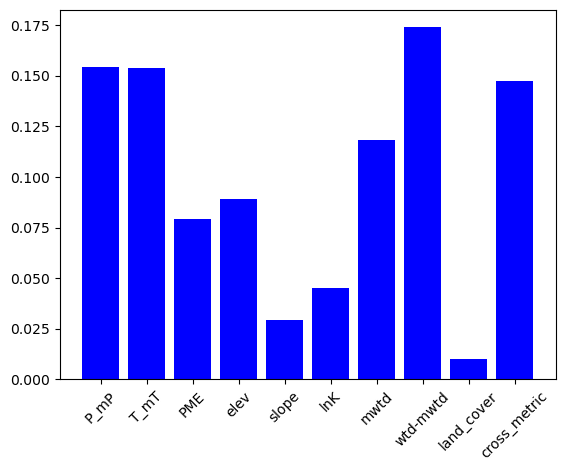

In [8]:
# # feature importance
# print(RF_model.rf_model.feature_importances_)
# # plot
# plt.bar(in_vars,RF_model.rf_model.feature_importances_,color='b')

print(RF_model.feature_importances_)
plt.bar(in_vars,RF_model.feature_importances_,color='b')
plt.xticks(rotation=45)
plt.show()

In [24]:
# Compute feature importance using permutation importance
result = permutation_importance(RF_model, X_test, y_test, n_repeats=30, random_state=0)
result.importances_mean

array([-0.0237785 , -0.13288197,  0.58683312, -0.13088956, -0.00121917,
       -0.04475693,  0.21144992, -0.0744922 , -0.03227972, -0.1385924 ])

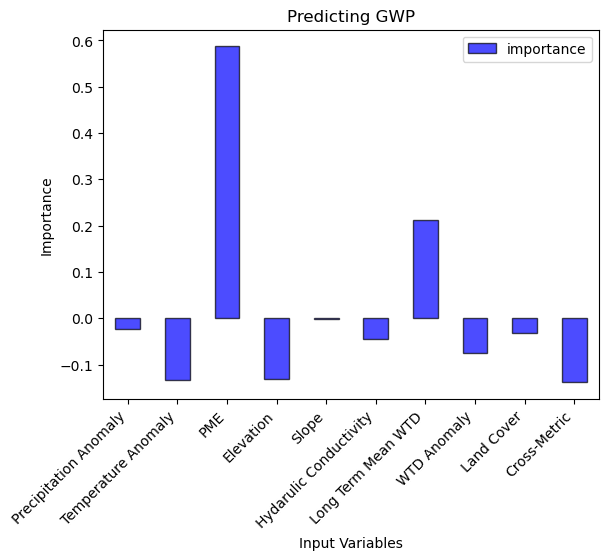

In [25]:
# Create a dataframe
import_df = pd.DataFrame()
import_df['importance'] = result.importances_mean
import_df['variables'] = in_vars

# Plot permutation importance
ax = import_df.plot.bar(x='variables', y='importance', color='blue', edgecolor='black', alpha=0.7)
plt.xlabel('Input Variables')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('Predicting GWP')

plt.savefig('permutation_gwp.png', dpi=300)

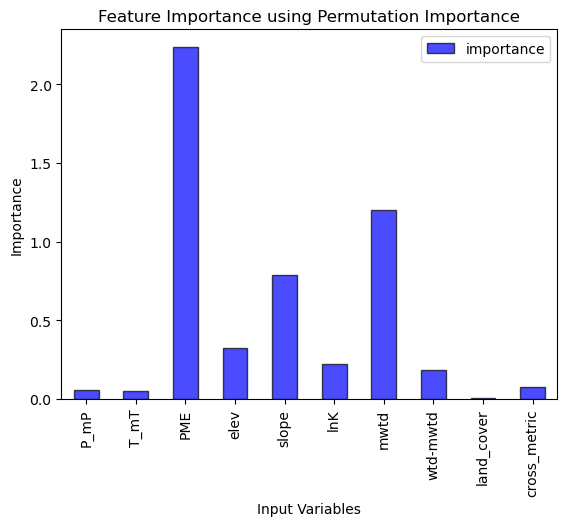

In [13]:
# Create a dataframe
import_df = pd.DataFrame()
import_df['importance'] = result.importances_mean
import_df['variables'] = in_vars

# Plot permutation importance
ax = import_df.plot.bar(x='variables', y='importance', color='blue', edgecolor='black', alpha=0.7)
plt.xlabel('Input Variables')
plt.ylabel('Importance')
plt.title('Feature Importance using Permutation Importance')

plt.show()

In [ ]:
# Compute feature importance using SHAP values
import shap

explainer = shap.Explainer(RF_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [10]:
# Pearson correlation coefficients
corr_df = pd.DataFrame()
corr_df['P_mP'] = X_test[:,0]
corr_df['T_mT'] = X_test[:,1]
corr_df['PME'] = X_test[:,2]
corr_df['elev'] = X_test[:,3]
corr_df['slope'] = X_test[:,4]
corr_df['lnK'] = X_test[:,5]
corr_df['mwtd'] = X_test[:,6]
corr_df['wtd_mwtd'] = X_test[:,7]
corr_df['land_cover'] = X_test[:,8]
corr_df['cross_metric1'] = X_test[:,9]
corr_df['Pumping_obs'] = y_test
corr_df['Pumping_est'] = np.array(test_results)[0]+lasso_test_results
correlation_matrix = corr_df.corr()
last_two_columns = correlation_matrix.iloc[:, -2:]
last_two_columns

# Pumping observations have the strongest correlation with PME
# Pumping estimations have the strongest correlation with PME
# Observations: PME, elev, T_mT, land_cover, slope, wtd_mwtd, lnK, mwtd, P_mP
# Estimations: PME, T_mT, elev, mwtd, land_cover, slope, wtd_mwtd, lnK, P_mP

,Pumping_obs,Pumping_est
P_mP,-0.011869,-0.010627
T_mT,0.054293,0.069301
PME,0.101274,0.094848
elev,0.063059,0.082314
slope,-0.025632,-0.020242
lnK,-0.022301,-0.016344
mwtd,-0.016047,-0.035897
wtd_mwtd,0.024820,0.024073
land_cover,-0.034304,-0.033837
cross_metric1,-0.054114,-0.068813


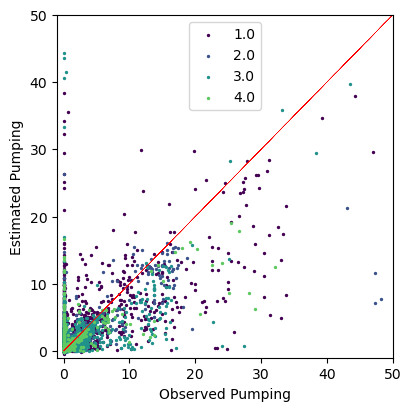

In [14]:
uniq = list(set(X_test[:, 8]))
fig, ax1 = plt.subplots(1, 1, figsize=(4, 4), constrained_layout=True)

cmap = plt.get_cmap('viridis')
cNorm = colors.Normalize(vmin=0, vmax=len(uniq))
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cmap)

for i, label in enumerate(uniq):
    indx = X_test[:, 8] == label
    color_val = scalarMap.to_rgba(i)
    ax1.scatter(y_test[indx], np.mean(np.array(test_results), axis=0)[indx] + lasso_test_results[indx],
                s=2, c=[color_val], label=label)

ax1.plot(y_test, y_test, 'r--', lw=0.1)

plt.xlim(-1, 50)
plt.ylim(-1, 50)
plt.legend()
plt.xlabel('Observed Pumping')
plt.ylabel('Estimated Pumping')
plt.show()

# 1: Urban, 2: Wetlands, 3: Forest, 4: Agriculture

/tmp/ipykernel_96006/332674903.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


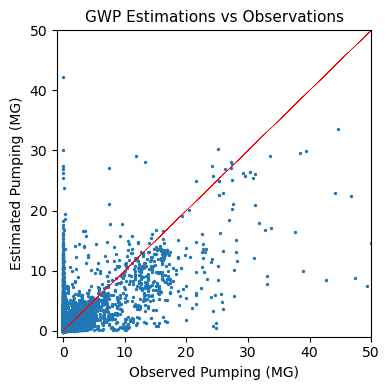

In [26]:
fig, ax1 = plt.subplots(1,1,figsize=(4,4),constrained_layout=True)
ax1.scatter(y_test,np.mean(np.array(test_results),axis=0)+lasso_test_results,s=2)
ax1.plot(y_test,y_test,'r--',lw=0.1)
plt.xlim(-1,50)
plt.ylim(-1,50)
plt.title('GWP Estimations vs Observations', fontsize=11)
plt.xlabel('Observed Pumping (MG)')
plt.ylabel('Estimated Pumping (MG)')
plt.tight_layout()
plt.savefig('gwp_scatter.png',dpi=300)

In [12]:
# Number of false positives in testing with cross metric using 4 diff input variables
zeros = y_test==0
true_indices = np.where(zeros[:,0])[0]
zero_pumping = X_test[true_indices,:]

threshold_values = [2, 5, 10]

# Iterate through different threshold values
for i in threshold_values:
    non_zeros = (np.mean(np.array(test_results), axis=0) + lasso_test_results > i)
    true_indices = np.where(zeros[:, 0] & non_zeros)[0]
    false_pos = X_test[true_indices, :]
    print(f"Threshold: {i}, False Positives: {len(false_pos)}")

Threshold: 2, False Positives: 328
Threshold: 5, False Positives: 113
Threshold: 10, False Positives: 43


# Mapping Data and Results

In [21]:
test_info = train_df.loc[test_index, :]

y_est = (np.mean(np.array(test_results), axis=0) + lasso_test_results).reshape(-1, 1)
y_test = y_test.flatten()
y_est = y_est.flatten()
pump_pred = pd.DataFrame({'y_true': y_test, 'y_pred': y_est})
test_loc = train_df.loc[test_index, ['x', 'y', 'HUC14']].reset_index(drop=True)
pump_pred = pd.merge(pump_pred, test_loc, left_index=True, right_index=True)
pump_pred['rmse'] = pump_pred['y_pred'] - pump_pred['y_true']

pump_pred.to_csv('pumping_predictions')

In [49]:
pump_pred

,y_true,y_pred,x,y,HUC14,rmse
0,0.027,0.148571,7208,26030,2040302080090,-0.121571
1,0.037,0.022285,7208,26030,2040302080090,0.014715
2,0.030,0.107967,7208,26030,2040302080090,-0.077967
3,0.019,0.152335,7208,26030,2040302080090,-0.133335
4,0.030,0.320312,7208,26030,2040302080090,-0.290312
...,...,...,...,...,...,...
9451,0.330,0.373715,7661,2198,2040104150020,-0.043715
9452,0.253,0.237510,7661,2198,2040104150020,0.015490
9453,0.233,0.240856,7661,2198,2040104150020,-0.007856
9454,0.281,0.218261,7661,2198,2040104150020,0.062739


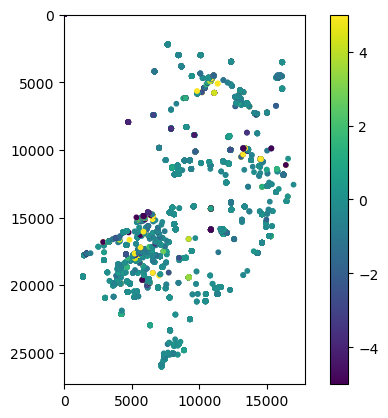

In [13]:
X_pixel_array = np.ones((200, 200))  # Replace this with your image data
X_pixel_array.fill(1)
plt.imshow(X_pixel_array)
plt.scatter(rmse_df['x'], rmse_df['y'], c=pump_pred['rmse'], cmap='viridis', s=10, vmin=-5, vmax=5)  # Adjust cmap and s as needed
plt.colorbar()
plt.show()

# These are the RMSE per site for WTD

In [113]:
train_df['HUC14']

0        2040302080090
1        2040302080090
2        2040302080090
3        2040302080090
4        2040302080090
             ...      
47275    2040104150020
47276    2040104150020
47277    2040104150020
47278    2040104150020
47279    2040104150020
Name: HUC14, Length: 47280, dtype: int64

In [114]:
train_df['elev']

,Unnamed: 0,OID_,ID,site_id_x,wtd,mwtd,latitude,longitude,x,y,...,LP5,LP6,LP7,LP8,LP9,YearNumber,MonthNumber,TransferEffectiveDate,WithdrawalMG,TYPE15_NUMBERED
0,0,252.0,1284052,3.856500e+14,6.277772,6.567527,38.947335,-74.926006,7208,26030,...,303.0,264.0,264.0,58.0,58.0,1990,2,02/01/90 00:00:00,0.023,2
1,1,253.0,1284053,3.856500e+14,6.202188,6.567527,38.947335,-74.926006,7208,26030,...,303.0,264.0,264.0,58.0,58.0,1990,3,03/01/90 00:00:00,0.023,2
2,2,254.0,1284054,3.856500e+14,6.088482,6.567527,38.947335,-74.926006,7208,26030,...,303.0,264.0,264.0,58.0,58.0,1990,4,04/01/90 00:00:00,0.023,2
3,3,255.0,1284055,3.856500e+14,6.046165,6.567527,38.947335,-74.926006,7208,26030,...,303.0,264.0,264.0,58.0,58.0,1990,5,05/01/90 00:00:00,0.025,2
4,4,256.0,1284056,3.856500e+14,6.100572,6.567527,38.947335,-74.926006,7208,26030,...,303.0,264.0,264.0,58.0,58.0,1990,6,06/01/90 00:00:00,0.019,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47275,47275,51111.0,1727316,4.109140e+14,6.490811,5.677856,41.153984,-74.884058,7661,2198,...,686.0,536.0,9600.0,4503.0,4503.0,2020,8,08/01/20 00:00:00,0.311,3
47276,47276,51112.0,1727317,4.109140e+14,6.214774,5.677856,41.153984,-74.884058,7661,2198,...,686.0,536.0,9600.0,4503.0,4503.0,2020,9,09/01/20 00:00:00,0.278,3
47277,47277,51113.0,1727318,4.109140e+14,6.635004,5.677856,41.153984,-74.884058,7661,2198,...,686.0,536.0,9600.0,4503.0,4503.0,2020,10,10/01/20 00:00:00,0.261,3
47278,47278,51114.0,1727319,4.109140e+14,5.630672,5.677856,41.153984,-74.884058,7661,2198,...,686.0,536.0,9600.0,4503.0,4503.0,2020,11,11/01/20 00:00:00,0.242,3


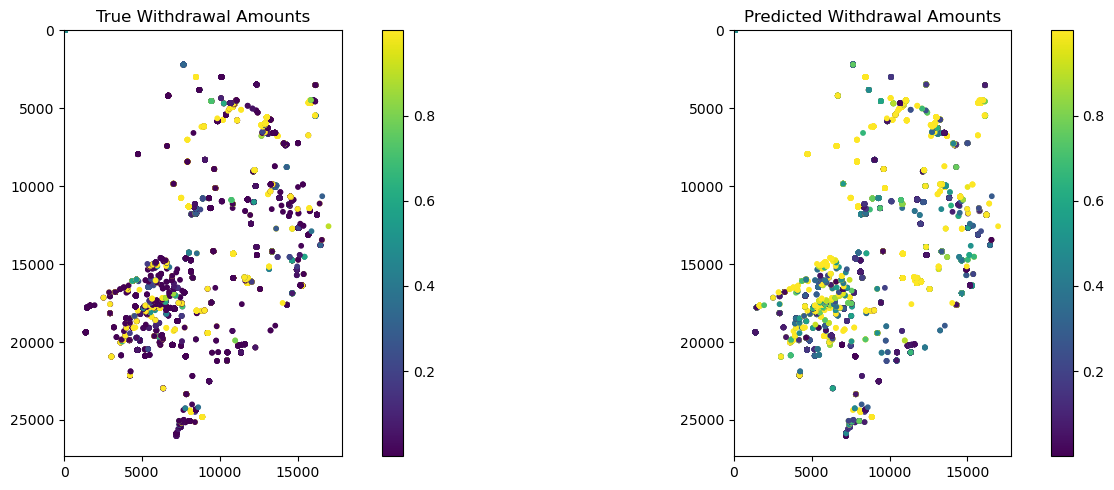

In [38]:
data = np.random.rand(200, 200)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))  # Adjust the number of subplots as needed

# Subplot 1
scatter1 = axs[0].imshow(data, cmap='viridis')
axs[0].scatter(rmse_df['x'], rmse_df['y'], c=rmse_df['y_true'], cmap='viridis', s=10, vmin=0, vmax=1)
axs[0].set_title('True Withdrawal Amounts')

# Subplot 2
scatter2 = axs[1].imshow(data, cmap='viridis')
axs[1].scatter(rmse_df['x'], rmse_df['y'], c=rmse_df['y_pred'], cmap='viridis', s=10, vmin=0, vmax=1)
axs[1].set_title('Predicted Withdrawal Amounts')

cbar1 = fig.colorbar(scatter1, ax=axs[0])
cbar2 = fig.colorbar(scatter2, ax=axs[1])

plt.tight_layout()

plt.show()

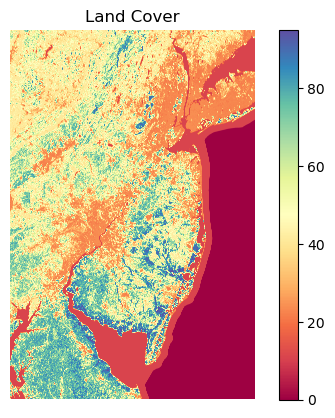

In [16]:
land_cover = rioxarray.open_rasterio('/home/jk48/Senior_Thesis/NJ_land_cover.tif')
land_cover = land_cover.data[0,:,:]
plt.imshow(land_cover,cmap='Spectral')
plt.axis('off')
plt.title('Land Cover')
plt.colorbar()

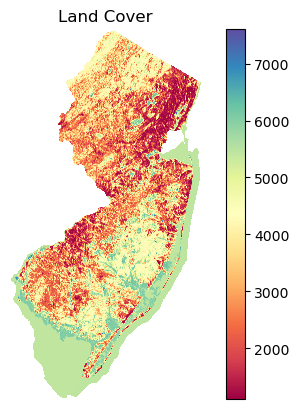

In [18]:
land_cover = rioxarray.open_rasterio('/home/jk48/Senior_Thesis/land_cover.tif')
land_cover = land_cover.data[0,:,:]
land_cover[land_cover==0] = np.nan
plt.imshow(land_cover,cmap='Spectral')
plt.axis('off')
plt.title('Land Cover')
plt.colorbar()
plt.savefig('landcover.png', dpi=300)

In [ ]:
colors = ['red', 'blue', 'green', 'purple']
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(len(categories)+1)-0.5, len(categories))
land_cover = rioxarray.open_rasterio('/home/jk48/Senior_Thesis/land_cover.tif')
land_cover = land_cover.data[0,:,:]
land_cover[land_cover==0] = np.nan
plt.imshow(land_cover,cmap='Spectral')
plt.axis('off')
plt.title('Land Cover')
plt.colorbar()
plt.savefig('landcover.png', dpi=300)

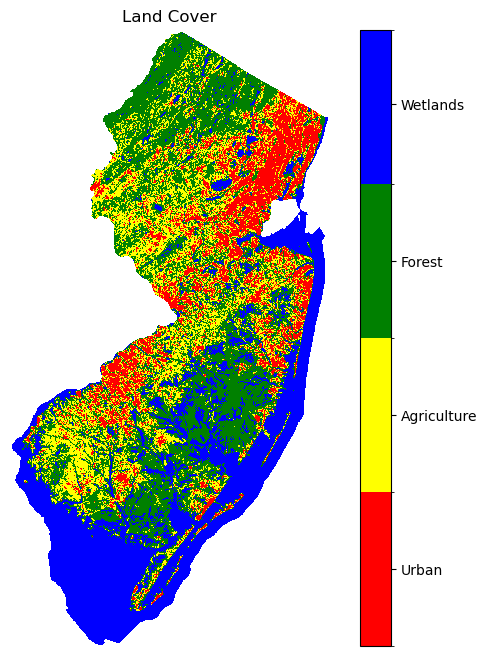

In [50]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colorbar import ColorbarBase

categories = ['Urban', 'Agriculture', 'Forest', 'Wetlands']
colors = ['red', 'yellow', 'green', 'blue']
cmap = ListedColormap(colors)

# Define the boundaries for the categories
bounds = [0, 2000, 3000, 5000, 7500]
norm = BoundaryNorm(bounds, cmap.N)

# Create some sample data
land_cover = rioxarray.open_rasterio('/home/jk48/Senior_Thesis/land_cover.tif')
land_cover = land_cover.data[0,:,:]
land_cover[land_cover==0] = np.nan

# Plot the data
fig, ax = plt.subplots(figsize=(8, 8))
cax = ax.imshow(land_cover, cmap=cmap, norm=norm)
ax.axis('off')
plt.title('Land Cover')

# Create a colorbar
cbar = fig.colorbar(cax, ticks=[1000, 2500, 4000, 6300], orientation='vertical')
cbar.ax.set_yticklabels(categories)

plt.savefig('landcover.png', dpi=300)

In [12]:
import rasterio
import pandas as pd
import numpy as np

# Open the GeoTIFF file
with rasterio.open('/home/jk48/Senior_Thesis/land_cover.tif') as dataset:
    # Read the data
    data = dataset.read(1)  # Read the first band
    # Get the coordinates
    rows, cols = np.meshgrid(np.arange(data.shape[0]), np.arange(data.shape[1]), indexing='ij')
    xs, ys = rasterio.transform.xy(dataset.transform, rows, cols)

# Flatten the arrays
data_flat = data.flatten()
xs_flat = np.array(xs).flatten()
ys_flat = np.array(ys).flatten()

# Create a DataFrame
df = pd.DataFrame({
    'x': xs_flat,
    'y': ys_flat,
    'value': data_flat
})

# Save to CSV
df.to_csv('/home/jk48/Senior_Thesis/land_cover.csv', index=False)

In [13]:
lu = pd.read_csv('/home/jk48/Senior_Thesis/land_cover.csv')

In [18]:
lu['value'].value_counts()

value
0.0       24544247
4120.0     3735041
5411.0     2748779
2100.0     2346163
1120.0     2042973
            ...   
1711.0         769
5190.0         682
1741.0         491
1411.0         451
6500.0         218
Name: count, Length: 87, dtype: int64

In [20]:
bins = [0, 2000, 3000, 5000, 7500]
labels = ['0-2000', '2000-3000', '3000-5000', '5000-7500']

# Create a new column 'group' that contains the group for each value
lu['group'] = pd.cut(lu['value'], bins=bins, labels=labels, include_lowest=True)

# Count the occurrences of each group
group_counts = lu['group'].value_counts()

# Print the group counts
print(group_counts)

group
0-2000       33065431
5000-7500    11652495
3000-5000     8168695
2000-3000     3311537
Name: count, dtype: int64


In [9]:
path = '/home/SHARED/data/ym5379/NJ_experiment/NJ_data/'
HUC14_3s_dataset = rioxarray.open_rasterio(path+'NJ_90m_HUC14.tif')
HUC14_3s_dataset

<xarray.DataArray (band: 1, y: 4057, x: 2144)>
[8698208 values with dtype=float64]
Coordinates:
  * band         (band) int64 1
  * x            (x) float64 -8.415e+06 -8.415e+06 ... -8.222e+06 -8.222e+06
  * y            (y) float64 5.065e+06 5.065e+06 5.065e+06 ... 4.7e+06 4.7e+06
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -9999.0
    scale_factor:   1.0
    add_offset:     0.0

In [10]:
HUC14_3s_data = HUC14_3s_dataset.data[0,:,:]
HUC14_3s_data[HUC14_3s_data==-9999] = np.nan

In [11]:
np.unique(HUC14_3s_data[~np.isnan(HUC14_3s_data)]).shape

(969,)

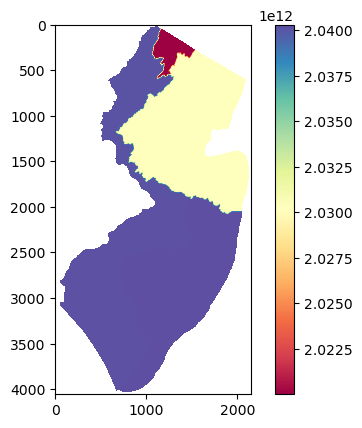

In [12]:
plt.imshow(HUC14_3s_data,cmap='Spectral')
plt.colorbar()

In [13]:
static_dataset = train_df[['TYPE15_NUMBERED', 'HUC14']].groupby('HUC14')['TYPE15_NUMBERED'].apply(lambda x: x.value_counts().idxmax())
static_dataset = static_dataset.drop(static_dataset.index[0])
static_dataset

HUC14
2030103010130    1
2030103010140    1
2030103010150    1
2030103010160    3
2030103020010    3
                ..
2040302080050    2
2040302080060    3
2040302080070    1
2040302080080    1
2040302080090    2
Name: TYPE15_NUMBERED, Length: 268, dtype: int64

In [14]:
train_df_90m_data = np.empty(HUC14_3s_data.shape) * np.nan
count = 0

for HUC14_index in np.unique(HUC14_3s_data[~np.isnan(HUC14_3s_data)]):
    print(HUC14_index)
    
    if static_dataset[static_dataset.index==int(HUC14_index)].shape[0] != 0:
        train_df_90m_data[HUC14_3s_data==HUC14_index] = static_dataset[static_dataset.index==int(HUC14_index)].values
    else:
        print(int(HUC14_index))
        count += 1
        train_df_90m_data[HUC14_3s_data==HUC14_index] = -1
            
print(count)

2020007000010.0
2020007000010
2020007010010.0
2020007010010
2020007010020.0
2020007010020
2020007010030.0
2020007010030
2020007010040.0
2020007010040
2020007010050.0
2020007010050
2020007010060.0
2020007010060
2020007010070.0
2020007010070
2020007010080.0
2020007010080
2020007020010.0
2020007020010
2020007020020.0
2020007020020
2020007020030.0
2020007020030
2020007020040.0
2020007020040
2020007020050.0
2020007020050
2020007020060.0
2020007020060
2020007020070.0
2020007020070
2020007030010.0
2020007030010
2020007030020.0
2020007030020
2020007030030.0
2020007030030
2020007030040.0
2020007030040
2020007040010.0
2020007040010
2020007040020.0
2020007040020
2020007040030.0
2020007040030
2020007040040.0
2020007040040
2020007040050.0
2020007040050
2020007040060.0
2020007040060
2030101170010.0
2030101170010
2030101170020.0
2030101170020
2030101170030.0
2030101170030
2030103010010.0
2030103010010
2030103010020.0
2030103010020
2030103010030.0
2030103010030
2030103010040.0
2030103010040
2030103010

2030105160030.0
2030105160040.0
2030105160040
2030105160050.0
2030105160060.0
2030105160070.0
2030105160080.0
2030105160080
2030105160090.0
2030105160090
2030105160100.0
2030105160100
2040104090010.0
2040104090010
2040104090020.0
2040104090020
2040104090030.0
2040104090030
2040104110010.0
2040104110010
2040104110020.0
2040104110020
2040104130010.0
2040104130010
2040104130020.0
2040104130020
2040104130030.0
2040104130030
2040104140010.0
2040104140010
2040104140020.0
2040104140020
2040104140030.0
2040104140030
2040104140040.0
2040104140040
2040104150010.0
2040104150010
2040104150020.0
2040104240010.0
2040104240010
2040104240020.0
2040104240020
2040105030010.0
2040105030010
2040105030020.0
2040105030030.0
2040105030030
2040105040010.0
2040105040010
2040105040020.0
2040105040020
2040105040030.0
2040105040030
2040105040040.0
2040105040040
2040105040050.0
2040105040060.0
2040105040060
2040105040070.0
2040105040070
2040105040080.0
2040105040080
2040105040090.0
2040105040090
2040105050010.0
20

2040206160010.0
2040206160020.0
2040206160030.0
2040206160030
2040206160040.0
2040206170010.0
2040206170010
2040206170020.0
2040206170020
2040206170030.0
2040206170030
2040206170040.0
2040206170040
2040206170050.0
2040206170050
2040206180010.0
2040206180020.0
2040206180020
2040206180030.0
2040206180030
2040206180040.0
2040206180040
2040206180050.0
2040206180050
2040206190010.0
2040206190010
2040206190020.0
2040206190020
2040206190030.0
2040206190030
2040206200010.0
2040206200010
2040206200020.0
2040206200020
2040206200030.0
2040206200030
2040206200040.0
2040206200040
2040206200050.0
2040206210010.0
2040206210010
2040206210020.0
2040206210020
2040206210030.0
2040206210030
2040206210040.0
2040206210040
2040206210050.0
2040206210050
2040206210060.0
2040206210060
2040206220010.0
2040206220010
2040206220020.0
2040206220030.0
2040206220030
2040206220040.0
2040206230010.0
2040206230020.0
2040206230030.0
2040206230030
2040206230040.0
2040206230050.0
2040206230060.0
2040206230060
2040206230070.

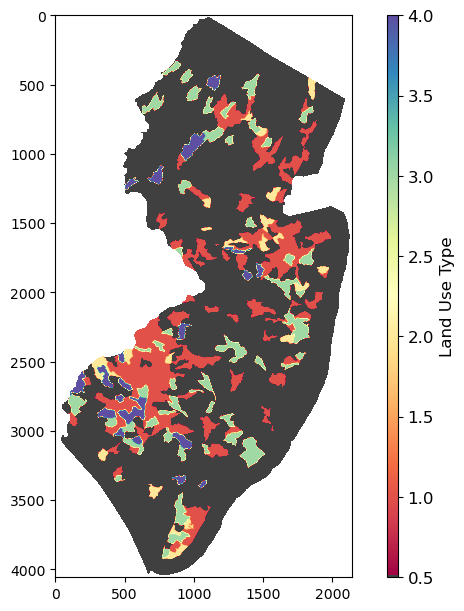

In [15]:
fig, ax1 = plt.subplots(1,1,figsize=(8,6),constrained_layout=True)

custom_value = 0
original_cmap = plt.cm.Spectral
new_color = [192,192,192,1]  # Black color as [R, G, B, alpha]
custom_cmap_colors = [original_cmap(i) for i in range(original_cmap.N)]
custom_cmap_colors[0] = new_color
custom_cmap = ListedColormap(custom_cmap_colors)
vmin = -1

im1 = plt.imshow(train_df_90m_data,vmin=0.5, cmap=custom_cmap)
cbar1 = plt.colorbar(im1,ax=ax1,shrink=1,aspect=50,orientation='vertical')
cbar1.set_label('Land Use Type',fontsize=12)
cbar1.ax.tick_params(labelsize=12)

# Urban, Wetlands, Forest, Agriculture (1, 2, 3, 4)
# Most common land use type in each HUC14
# not sure if completely accurate - the points are only of those closest to wells

In [29]:
static_dataset = pump_pred[['y_pred', 'HUC14']].groupby('HUC14')['y_pred'].mean().sort_index()
static_dataset = static_dataset.drop(static_dataset.index[0])
static_dataset

HUC14
2030103010130     0.579146
2030103010140     0.319531
2030103010150     0.998387
2030103010160     0.565021
2030103020010    32.662116
                   ...    
2040302080050     0.155665
2040302080060     0.669475
2040302080070     3.120104
2040302080080     0.164027
2040302080090     0.107635
Name: y_pred, Length: 258, dtype: float64

In [30]:
train_df_90m_data = np.empty(HUC14_3s_data.shape) * np.nan
count = 0

for HUC14_index in np.unique(HUC14_3s_data[~np.isnan(HUC14_3s_data)]):
    print(HUC14_index)
    
    if static_dataset[static_dataset.index==int(HUC14_index)].shape[0] != 0:
        train_df_90m_data[HUC14_3s_data==HUC14_index] = static_dataset[static_dataset.index==int(HUC14_index)].values
    else:
        print(int(HUC14_index))
        count += 1
        train_df_90m_data[HUC14_3s_data==HUC14_index] = -1
            
print(count)

2020007000010.0
2020007000010
2020007010010.0
2020007010010
2020007010020.0
2020007010020
2020007010030.0
2020007010030
2020007010040.0
2020007010040
2020007010050.0
2020007010050
2020007010060.0
2020007010060
2020007010070.0
2020007010070
2020007010080.0
2020007010080
2020007020010.0
2020007020010
2020007020020.0
2020007020020
2020007020030.0
2020007020030
2020007020040.0
2020007020040
2020007020050.0
2020007020050
2020007020060.0
2020007020060
2020007020070.0
2020007020070
2020007030010.0
2020007030010
2020007030020.0
2020007030020
2020007030030.0
2020007030030
2020007030040.0
2020007030040
2020007040010.0
2020007040010
2020007040020.0
2020007040020
2020007040030.0
2020007040030
2020007040040.0
2020007040040
2020007040050.0
2020007040050
2020007040060.0
2020007040060
2030101170010.0
2030101170010
2030101170020.0
2030101170020
2030101170030.0
2030101170030
2030103010010.0
2030103010010
2030103010020.0
2030103010020
2030103010030.0
2030103010030
2030103010040.0
2030103010040
2030103010

2030105150060.0
2030105160010.0
2030105160020.0
2030105160030.0
2030105160040.0
2030105160040
2030105160050.0
2030105160060.0
2030105160070.0
2030105160080.0
2030105160080
2030105160090.0
2030105160090
2030105160100.0
2030105160100
2040104090010.0
2040104090010
2040104090020.0
2040104090020
2040104090030.0
2040104090030
2040104110010.0
2040104110010
2040104110020.0
2040104110020
2040104130010.0
2040104130010
2040104130020.0
2040104130020
2040104130030.0
2040104130030
2040104140010.0
2040104140010
2040104140020.0
2040104140020
2040104140030.0
2040104140030
2040104140040.0
2040104140040
2040104150010.0
2040104150010
2040104150020.0
2040104240010.0
2040104240010
2040104240020.0
2040104240020
2040105030010.0
2040105030010
2040105030020.0
2040105030030.0
2040105030030
2040105040010.0
2040105040010
2040105040020.0
2040105040020
2040105040030.0
2040105040030
2040105040040.0
2040105040040
2040105040050.0
2040105040060.0
2040105040060
2040105040070.0
2040105040070
2040105040080.0
2040105040080


2040206140060.0
2040206140070.0
2040206140070
2040206150010.0
2040206150020.0
2040206150030.0
2040206150040.0
2040206150050.0
2040206150060.0
2040206150060
2040206150070.0
2040206160010.0
2040206160020.0
2040206160030.0
2040206160030
2040206160040.0
2040206170010.0
2040206170010
2040206170020.0
2040206170020
2040206170030.0
2040206170030
2040206170040.0
2040206170040
2040206170050.0
2040206170050
2040206180010.0
2040206180020.0
2040206180020
2040206180030.0
2040206180030
2040206180040.0
2040206180040
2040206180050.0
2040206180050
2040206190010.0
2040206190010
2040206190020.0
2040206190020
2040206190030.0
2040206190030
2040206200010.0
2040206200010
2040206200020.0
2040206200020
2040206200030.0
2040206200030
2040206200040.0
2040206200040
2040206200050.0
2040206210010.0
2040206210010
2040206210020.0
2040206210020
2040206210030.0
2040206210030
2040206210040.0
2040206210040
2040206210050.0
2040206210050
2040206210060.0
2040206210060
2040206220010.0
2040206220010
2040206220020.0
204020622003

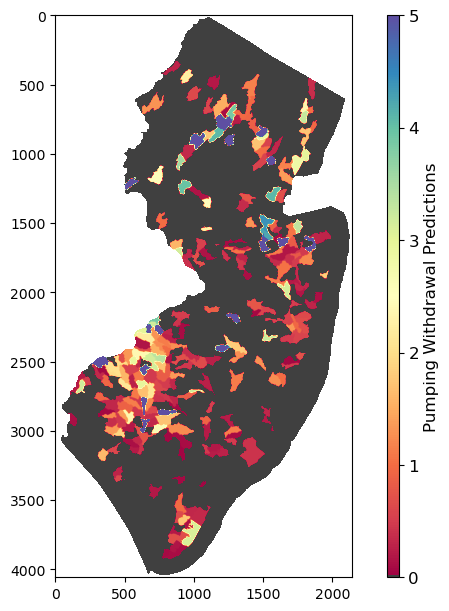

In [31]:
fig, ax1 = plt.subplots(1,1,figsize=(8,6),constrained_layout=True)

custom_value = -1
original_cmap = plt.cm.Spectral
new_color = [192,192,192,1]  # Black color as [R, G, B, alpha]
custom_cmap_colors = [original_cmap(i) for i in range(original_cmap.N)]
custom_cmap_colors[0] = new_color
custom_cmap = ListedColormap(custom_cmap_colors)
vmin = -1

im1 = plt.imshow(train_df_90m_data,vmin=0, vmax=5, cmap=custom_cmap)
cbar1 = plt.colorbar(im1,ax=ax1,shrink=1,aspect=50,orientation='vertical')
cbar1.set_label('Pumping Withdrawal Predictions',fontsize=12)
cbar1.ax.tick_params(labelsize=12)

In [32]:
static_dataset = pump_pred[['y_true', 'HUC14']].groupby('HUC14')['y_true'].mean().sort_index()
static_dataset = static_dataset.drop(static_dataset.index[0])
static_dataset

HUC14
2030103010130     0.557154
2030103010140     0.329000
2030103010150     0.933789
2030103010160     0.590500
2030103020010    19.575417
                   ...    
2040302080050     0.196257
2040302080060     0.467507
2040302080070     2.968846
2040302080080     0.112481
2040302080090     0.031000
Name: y_true, Length: 258, dtype: float32

In [33]:
train_df_90m_data = np.empty(HUC14_3s_data.shape) * np.nan
count = 0

for HUC14_index in np.unique(HUC14_3s_data[~np.isnan(HUC14_3s_data)]):
    print(HUC14_index)
    
    if static_dataset[static_dataset.index==int(HUC14_index)].shape[0] != 0:
        train_df_90m_data[HUC14_3s_data==HUC14_index] = static_dataset[static_dataset.index==int(HUC14_index)].values
    else:
        print(int(HUC14_index))
        count += 1
        train_df_90m_data[HUC14_3s_data==HUC14_index] = -1
            
print(count)

2020007000010.0
2020007000010
2020007010010.0
2020007010010
2020007010020.0
2020007010020
2020007010030.0
2020007010030
2020007010040.0
2020007010040
2020007010050.0
2020007010050
2020007010060.0
2020007010060
2020007010070.0
2020007010070
2020007010080.0
2020007010080
2020007020010.0
2020007020010
2020007020020.0
2020007020020
2020007020030.0
2020007020030
2020007020040.0
2020007020040
2020007020050.0
2020007020050
2020007020060.0
2020007020060
2020007020070.0
2020007020070
2020007030010.0
2020007030010
2020007030020.0
2020007030020
2020007030030.0
2020007030030
2020007030040.0
2020007030040
2020007040010.0
2020007040010
2020007040020.0
2020007040020
2020007040030.0
2020007040030
2020007040040.0
2020007040040
2020007040050.0
2020007040050
2020007040060.0
2020007040060
2030101170010.0
2030101170010
2030101170020.0
2030101170020
2030101170030.0
2030101170030
2030103010010.0
2030103010010
2030103010020.0
2030103010020
2030103010030.0
2030103010030
2030103010040.0
2030103010040
2030103010

2030105110160.0
2030105110160
2030105110170.0
2030105110170
2030105120010.0
2030105120010
2030105120020.0
2030105120020
2030105120030.0
2030105120030
2030105120040.0
2030105120040
2030105120050.0
2030105120050
2030105120060.0
2030105120060
2030105120070.0
2030105120070
2030105120080.0
2030105120080
2030105120090.0
2030105120090
2030105120100.0
2030105120100
2030105120110.0
2030105120110
2030105120120.0
2030105120130.0
2030105120130
2030105120140.0
2030105120140
2030105120150.0
2030105120150
2030105120160.0
2030105120170.0
2030105120170
2030105120180.0
2030105120180
2030105130010.0
2030105130010
2030105130020.0
2030105130020
2030105130030.0
2030105130030
2030105130040.0
2030105130040
2030105130050.0
2030105130050
2030105130060.0
2030105130070.0
2030105130070
2030105140010.0
2030105140010
2030105140020.0
2030105140020
2030105140030.0
2030105140030
2030105150010.0
2030105150020.0
2030105150030.0
2030105150040.0
2030105150040
2030105150050.0
2030105150050
2030105150060.0
2030105160010.0
20

2040206100020.0
2040206100020
2040206100030.0
2040206100030
2040206100040.0
2040206100040
2040206100050.0
2040206100060.0
2040206100060
2040206100070.0
2040206110010.0
2040206110010
2040206110020.0
2040206110020
2040206110030.0
2040206110030
2040206110040.0
2040206110040
2040206110050.0
2040206110050
2040206110060.0
2040206110060
2040206110070.0
2040206110070
2040206120010.0
2040206120020.0
2040206120030.0
2040206120040.0
2040206120050.0
2040206130010.0
2040206130020.0
2040206130030.0
2040206130040.0
2040206140010.0
2040206140020.0
2040206140030.0
2040206140030
2040206140040.0
2040206140050.0
2040206140050
2040206140060.0
2040206140070.0
2040206140070
2040206150010.0
2040206150020.0
2040206150030.0
2040206150040.0
2040206150050.0
2040206150060.0
2040206150060
2040206150070.0
2040206160010.0
2040206160020.0
2040206160030.0
2040206160030
2040206160040.0
2040206170010.0
2040206170010
2040206170020.0
2040206170020
2040206170030.0
2040206170030
2040206170040.0
2040206170040
2040206170050.0


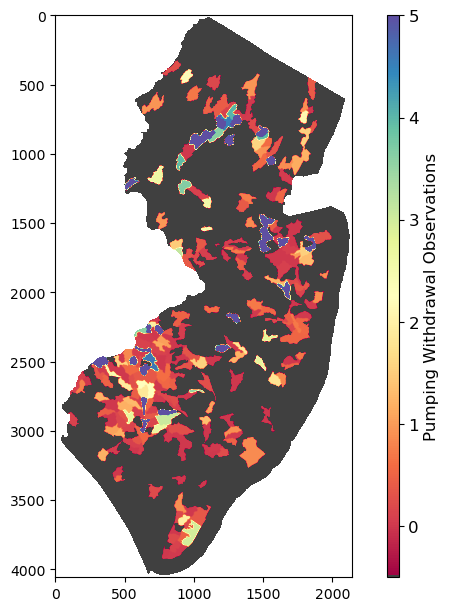

In [36]:
fig, ax1 = plt.subplots(1,1,figsize=(8,6),constrained_layout=True)

custom_value = -1
original_cmap = plt.cm.Spectral
new_color = [192,192,192,1]
custom_cmap_colors = [original_cmap(i) for i in range(original_cmap.N)]
custom_cmap_colors[0] = new_color
custom_cmap = ListedColormap(custom_cmap_colors)

im1 = plt.imshow(train_df_90m_data,vmin=-0.5, vmax=5, cmap=custom_cmap)
cbar1 = plt.colorbar(im1,ax=ax1,shrink=1,aspect=50,orientation='vertical')
cbar1.set_label('Pumping Withdrawal Observations',fontsize=12)
cbar1.ax.tick_params(labelsize=12)

In [19]:
static_dataset = pump_pred[['rmse', 'HUC14']].groupby('HUC14')['rmse'].mean().sort_index()
static_dataset = static_dataset.drop(static_dataset.index[0])
static_dataset

HUC14
2030103010130     0.021992
2030103010140    -0.009469
2030103010150     0.064597
2030103010160    -0.025479
2030103020010    13.086699
                   ...    
2040302080050    -0.040593
2040302080060     0.201968
2040302080070     0.151258
2040302080080     0.051546
2040302080090     0.076635
Name: rmse, Length: 258, dtype: float64

In [24]:
train_df_90m_data = np.empty(HUC14_3s_data.shape) * np.nan
count = 0

for HUC14_index in np.unique(HUC14_3s_data[~np.isnan(HUC14_3s_data)]):
    print(HUC14_index)
    
    if static_dataset[static_dataset.index==int(HUC14_index)].shape[0] != 0:
        train_df_90m_data[HUC14_3s_data==HUC14_index] = static_dataset[static_dataset.index==int(HUC14_index)].values
    else:
        print(int(HUC14_index))
        count += 1
        train_df_90m_data[HUC14_3s_data==HUC14_index] = -5.5
            
print(count)

2020007000010.0
2020007000010
2020007010010.0
2020007010010
2020007010020.0
2020007010020
2020007010030.0
2020007010030
2020007010040.0
2020007010040
2020007010050.0
2020007010050
2020007010060.0
2020007010060
2020007010070.0
2020007010070
2020007010080.0
2020007010080
2020007020010.0
2020007020010
2020007020020.0
2020007020020
2020007020030.0
2020007020030
2020007020040.0
2020007020040
2020007020050.0
2020007020050
2020007020060.0
2020007020060
2020007020070.0
2020007020070
2020007030010.0
2020007030010
2020007030020.0
2020007030020
2020007030030.0
2020007030030
2020007030040.0
2020007030040
2020007040010.0
2020007040010
2020007040020.0
2020007040020
2020007040030.0
2020007040030
2020007040040.0
2020007040040
2020007040050.0
2020007040050
2020007040060.0
2020007040060
2030101170010.0
2030101170010
2030101170020.0
2030101170020
2030101170030.0
2030101170030
2030103010010.0
2030103010010
2030103010020.0
2030103010020
2030103010030.0
2030103010030
2030103010040.0
2030103010040
2030103010

2030105160060.0
2030105160070.0
2030105160080.0
2030105160080
2030105160090.0
2030105160090
2030105160100.0
2030105160100
2040104090010.0
2040104090010
2040104090020.0
2040104090020
2040104090030.0
2040104090030
2040104110010.0
2040104110010
2040104110020.0
2040104110020
2040104130010.0
2040104130010
2040104130020.0
2040104130020
2040104130030.0
2040104130030
2040104140010.0
2040104140010
2040104140020.0
2040104140020
2040104140030.0
2040104140030
2040104140040.0
2040104140040
2040104150010.0
2040104150010
2040104150020.0
2040104240010.0
2040104240010
2040104240020.0
2040104240020
2040105030010.0
2040105030010
2040105030020.0
2040105030030.0
2040105030030
2040105040010.0
2040105040010
2040105040020.0
2040105040020
2040105040030.0
2040105040030
2040105040040.0
2040105040040
2040105040050.0
2040105040060.0
2040105040060
2040105040070.0
2040105040070
2040105040080.0
2040105040080
2040105040090.0
2040105040090
2040105050010.0
2040105050010
2040105050020.0
2040105050020
2040105050030.0
2040

2040206180040.0
2040206180040
2040206180050.0
2040206180050
2040206190010.0
2040206190010
2040206190020.0
2040206190020
2040206190030.0
2040206190030
2040206200010.0
2040206200010
2040206200020.0
2040206200020
2040206200030.0
2040206200030
2040206200040.0
2040206200040
2040206200050.0
2040206210010.0
2040206210010
2040206210020.0
2040206210020
2040206210030.0
2040206210030
2040206210040.0
2040206210040
2040206210050.0
2040206210050
2040206210060.0
2040206210060
2040206220010.0
2040206220010
2040206220020.0
2040206220030.0
2040206220030
2040206220040.0
2040206230010.0
2040206230020.0
2040206230030.0
2040206230030
2040206230040.0
2040206230050.0
2040206230060.0
2040206230060
2040206230070.0
2040206910010.0
2040206910010
2040206910020.0
2040206910020
2040206910030.0
2040206910030
2040206910040.0
2040206910040
2040206910050.0
2040206910050
2040206910060.0
2040206910060
2040206910070.0
2040206910070
2040301020010.0
2040301020020.0
2040301020030.0
2040301020030
2040301020040.0
2040301020050.

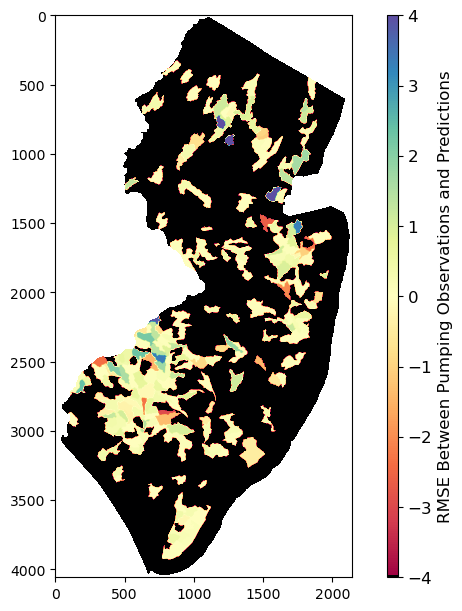

In [30]:
fig, ax1 = plt.subplots(1,1,figsize=(8,6),constrained_layout=True)

custom_value = -1
original_cmap = plt.cm.Spectral
new_color = [0, 0, 255, 1]
custom_cmap_colors = [original_cmap(i) for i in range(original_cmap.N)]
custom_cmap_colors[0] = new_color
custom_cmap = ListedColormap(custom_cmap_colors)

im1 = plt.imshow(train_df_90m_data,vmin=-4, vmax=4, cmap=custom_cmap)
cbar1 = plt.colorbar(im1,ax=ax1,shrink=1,aspect=50,orientation='vertical')
cbar1.set_label('RMSE Between Pumping Observations and Predictions',fontsize=12)
cbar1.ax.tick_params(labelsize=12)

In [79]:
# Find the average pumping rate for each type of landcover/use
average_values = train_df.groupby('TYPE15_NUMBERED')['WithdrawalMG'].mean().reset_index()
category_mapping = {1:'URBAN', 2:'WETLANDS', 3:'FOREST', 4:'AGRICULTURE'}
average_values['TYPE15_NUMBERED'] = average_values['TYPE15_NUMBERED'].map(category_mapping)
average_values.rename(columns={'TYPE15_NUMBERED':'Land Use Type'},inplace=True)
average_values 

# In terms of amount, most pumping takes place in Wetlands and the least in Forest

,Land Use Type,WithdrawalMG
0,URBAN,1.565074
1,WETLANDS,2.091892
2,FOREST,1.072459
3,AGRICULTURE,1.205335


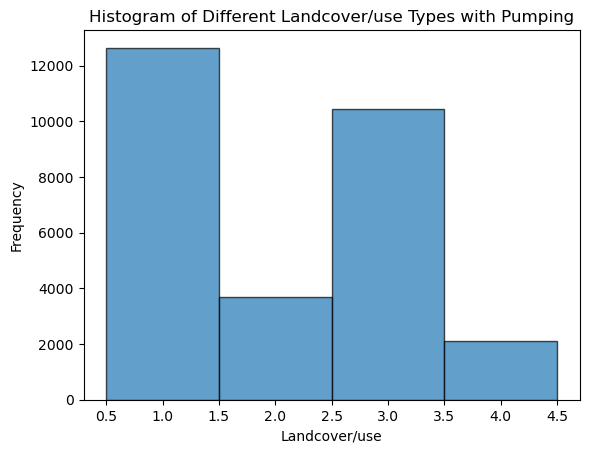

In [85]:
# Landcover types with pumping for all of the data
with_pumping_df = train_df[train_df['WithdrawalMG'] != 0]
LU_array = with_pumping_df['TYPE15_NUMBERED'].values

plt.hist(LU_array, bins=np.arange(min(LU_array), max(LU_array) + 1.5) - 0.5, edgecolor='black', alpha=0.7)
plt.xlabel('Landcover/use')
plt.ylabel('Frequency')
plt.title('Histogram of Different Landcover/use Types with Pumping')
plt.show()

# 1 - Urban, 2 - Wetlands, 3 - Forest, 4 - Agriculture
# In terms of frequency, most pumping tales place in Urban and least in Agriculture

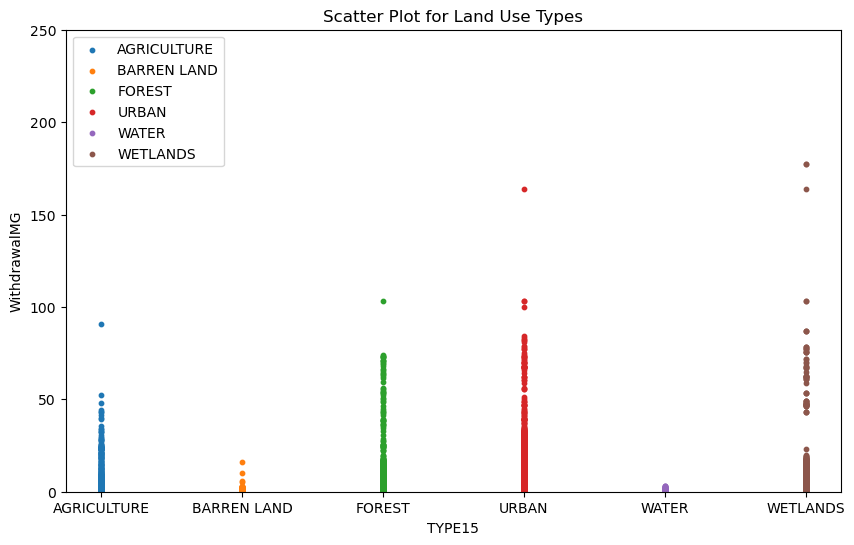

In [81]:
# Scatterplots for each type of land use type

grouped = train_df.groupby('TYPE15')

fig, ax = plt.subplots(figsize=(10, 6))

for (category, group) in grouped:
    ax.scatter(group['TYPE15'], group['WithdrawalMG'], label=category, s=10)

ax.set_title('Scatter Plot for Land Use Types')
ax.set_xlabel('TYPE15')
ax.set_ylabel('WithdrawalMG')
ax.legend()
ax.set_ylim(0, 250) 
plt.show()

In [142]:
# Find the average pumping rate for each type of landcover/use (Training and testing sets)
average_values = train_df.groupby('TYPE15_NUMBERED')['WithdrawalMG'].mean().reset_index()
category_mapping = {1:'URBAN', 2:'WETLANDS', 3:'FOREST', 4:'BARREN LAND', 5:'AGRICULTURE', 6:'WATER'}
average_values['TYPE15_NUMBERED'] = average_values['TYPE15_NUMBERED'].map(category_mapping)
average_values.rename(columns={'TYPE15_NUMBERED':'Land Use Type'},inplace=True)
average_values 

# In terms of amount, most pumping takes place in Wetlands and the least in Water

,Land Use Type,WithdrawalMG
0,URBAN,1.605738
1,WETLANDS,2.787428
2,FOREST,1.042144
3,BARREN LAND,0.763704
4,AGRICULTURE,1.389989
5,WATER,0.336571


In [14]:
average_values = train_df.groupby('TYPE15_NUMBERED')['WithdrawalMG'].mean().reset_index()
category_mapping = {1:'URBAN', 2:'WETLANDS', 3:'FOREST', 4:'AGRICULTURE'}
average_values['TYPE15_NUMBERED'] = average_values['TYPE15_NUMBERED'].map(category_mapping)
average_values.rename(columns={'TYPE15_NUMBERED':'Land Use Type'},inplace=True)
average_values

,Land Use Type,WithdrawalMG
0,URBAN,1.565074
1,WETLANDS,2.091892
2,FOREST,1.072459
3,AGRICULTURE,1.205335


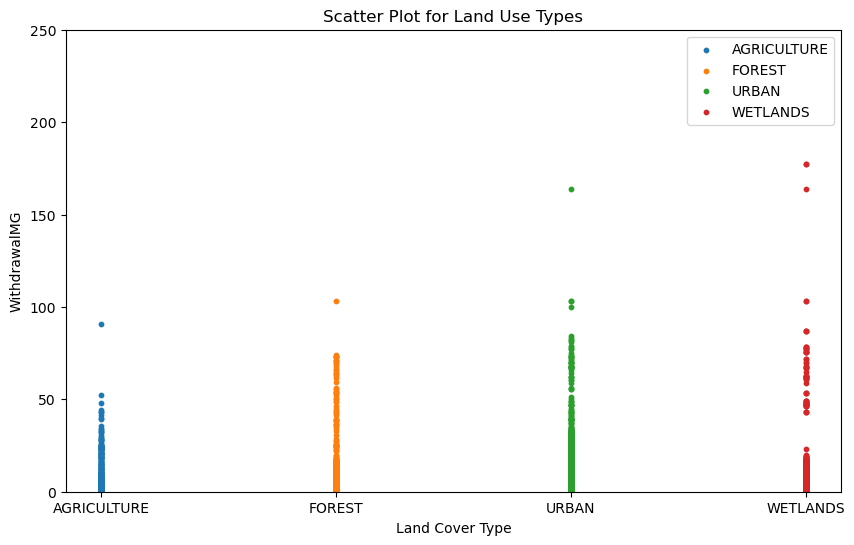

In [12]:
category_mapping = {1:'URBAN', 2:'WETLANDS', 3:'FOREST', 4:'AGRICULTURE'}
train_df['TYPE15_SIMPLIFIED'] = train_df['TYPE15_NUMBERED'].map(category_mapping)
count = type15.value_counts()

grouped = train_df.groupby('TYPE15_SIMPLIFIED')

fig, ax = plt.subplots(figsize=(10, 6))

for (category, group) in grouped:
    ax.scatter(group['TYPE15_SIMPLIFIED'], group['WithdrawalMG'], label=category, s=10)

ax.set_title('Scatter Plot for Land Use Types')
ax.set_xlabel('Land Use Type')
ax.set_ylabel('WithdrawalMG')
ax.legend()
ax.set_ylim(0, 250) 
plt.show()

# Sites with No Pumping Data Analysis (False Positives)

In [60]:
# Number of false positives in testing without cross metrics
zeros = y_test==0
true_indices = np.where(zeros[:,0])[0]
zero_pumping = X_test[true_indices,:]

threshold_values = [2, 5, 10]

# Iterate through different threshold values
for i in threshold_values:
    non_zeros = (np.mean(np.array(test_results), axis=0) + lasso_test_results > i)
    true_indices = np.where(zeros[:, 0] & non_zeros)[0]
    false_pos = X_test[true_indices, :]
    print(f"Threshold: {i}, False Positives: {len(false_pos)}")

Threshold: 2, False Positives: 325
Threshold: 5, False Positives: 124
Threshold: 10, False Positives: 50


In [68]:
# Number of false positives in testing with 2 cross metrics
zeros = y_test==0
true_indices = np.where(zeros[:,0])[0]
zero_pumping = X_test[true_indices,:]

threshold_values = [2, 5, 10]

# Iterate through different threshold values
for i in threshold_values:
    non_zeros = (np.mean(np.array(test_results), axis=0) + lasso_test_results > i)
    true_indices = np.where(zeros[:, 0] & non_zeros)[0]
    false_pos = X_test[true_indices, :]
    print(f"Threshold: {i}, False Positives: {len(false_pos)}")

Threshold: 2, False Positives: 322
Threshold: 5, False Positives: 110
Threshold: 10, False Positives: 41


In [114]:
# Number of false positives in testing with 3 cross metrics
# This results in the highest R
zeros = y_test==0
true_indices = np.where(zeros[:,0])[0]
zero_pumping = X_test[true_indices,:]

threshold_values = [2, 5, 10]

# Iterate through different threshold values
for i in threshold_values:
    non_zeros = (np.mean(np.array(test_results), axis=0) + lasso_test_results > i)
    true_indices = np.where(zeros[:, 0] & non_zeros)[0]
    false_pos = X_test[true_indices, :]
    print(f"Threshold: {i}, False Positives: {len(false_pos)}")

Threshold: 2, False Positives: 332
Threshold: 5, False Positives: 112
Threshold: 10, False Positives: 39


In [12]:
# Number of sites with no pumping
count_zeros = (train_df['WithdrawalMG'] == 0).sum()
print('Sites with 0 pumping:', count_zeros)
print('Total # of sites:', len(train_df))
print('Percentage:', count_zeros/len(train_df))

Sites with 0 pumping: 18419
Total # of sites: 47280
Percentage: 0.389572758037225


In [86]:
# Number of sites with no pumping (testing)
count_zeros = (y_test == 0).sum()
print('Sites with 0 pumping:', count_zeros)
print('Total # of sites:', len(y_test))
print('Percentage:', count_zeros/len(y_test))

Sites with 0 pumping: 3687
Total # of sites: 9456
Percentage: 0.38991116751269034


In [7]:
train_df['TYPE15'].value_counts()

TYPE15
URBAN          20228
FOREST         16873
WETLANDS        6146
AGRICULTURE     3581
BARREN LAND      268
WATER            184
Name: count, dtype: int64

In [11]:
train_df['LU15'].value_counts()

LU15
4120.0    5085
6210.0    4588
1700.0    4153
4312.0    2688
2100.0    2448
1214.0    2184
1800.0    2164
4322.0    2082
1140.0    1904
1200.0    1748
4311.0    1651
4220.0    1420
4410.0    1257
1300.0    1223
1463.0    1158
1400.0    1042
4440.0     995
4210.0     832
1120.0     821
1130.0     716
1110.0     712
1420.0     653
2400.0     628
1150.0     515
2200.0     505
1211.0     487
6220.0     481
4430.0     385
1850.0     377
4420.0     358
1499.0     320
7500.0     268
1410.0     223
2140.0     211
6251.0     199
5100.0     182
4110.0     114
1810.0     104
6221.0      82
1750.0      77
6111.0      59
1804.0      53
7430.0      47
1600.0      20
1440.0      16
6240.0       9
6252.0       9
1461.0       7
4321.0       6
1462.0       6
1500.0       6
5300.0       2
Name: count, dtype: int64

In [32]:
# Number of each land cover sites with pumping
with_pumping_df = train_df[train_df['WithdrawalMG'] != 0]
land_cover_count_pumping = with_pumping_df['TYPE15'].value_counts()
land_cover_count_pumping

TYPE15
URBAN          12439
FOREST         10447
WETLANDS        3596
AGRICULTURE     2094
BARREN LAND      201
WATER             84
Name: count, dtype: int64

In [33]:
# Number of each land cover sites with no pumping
no_pumping_df = train_df[train_df['WithdrawalMG'] == 0]
land_cover_count_no_pumping = no_pumping_df['TYPE15'].value_counts()
land_cover_count_no_pumping

TYPE15
URBAN          7789
FOREST         6426
WETLANDS       2550
AGRICULTURE    1487
WATER           100
BARREN LAND      67
Name: count, dtype: int64

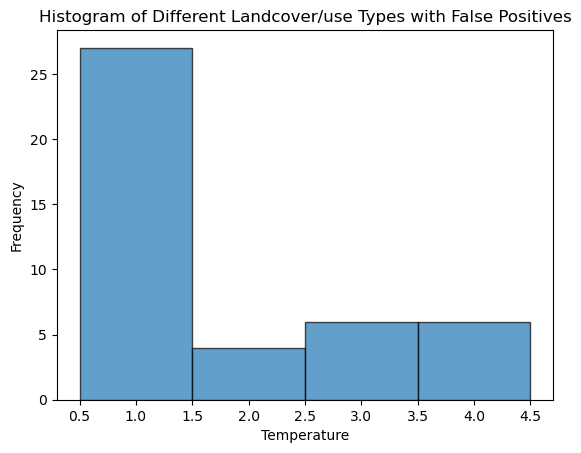

In [40]:
# mwtd frequencies for false positives
LU_array = false_pos[:,8]
plt.hist(LU_array, bins=np.arange(min(LU_array), max(LU_array) + 1.5) - 0.5, edgecolor='black', alpha=0.7)
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Histogram of Different Landcover/use Types with False Positives')
plt.show()

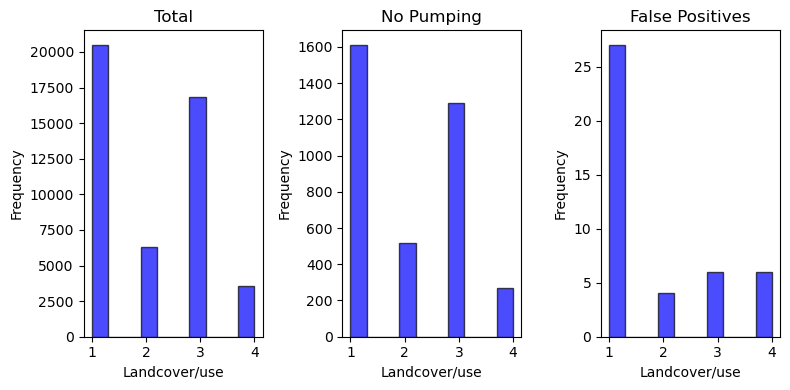

In [19]:
# Frequency of Landcover/use Types in No Pumping Sites and False Positives (testing sample)
zeros = y_test==0
true_indices = np.where(zeros[:,0])[0] # 3678
zero_pumping = X_test[true_indices,:]
non_zeros = (np.mean(np.array(test_results),axis=0)+lasso_test_results > 10)
true_indices = np.where(zeros[:,0] & non_zeros)[0] #665 points
false_pos = X_test[true_indices,:]

# Histogram for Landcover/use types with no pumping
LU_array_no_pumping = zero_pumping[:, 8]
mask = ~np.any(X == -9999, axis=1)
X = X[mask]

plt.figure(figsize=(8, 4))

plt.subplot(1, 3, 1)
plt.hist(X[:,8], edgecolor='black', color='blue', alpha=0.7)
plt.xlabel('Landcover/use')
plt.ylabel('Frequency')
plt.title('Total')

plt.subplot(1, 3, 2)
plt.hist(LU_array_no_pumping, edgecolor='black', color='blue', alpha=0.7)
plt.xlabel('Landcover/use')
plt.ylabel('Frequency')
plt.title('No Pumping')

# Histogram for Landcover/use types with false positives
LU_array_false_pos = false_pos[:, 8]
plt.subplot(1, 3, 3)
plt.hist(LU_array_false_pos, edgecolor='black', color='blue', alpha=0.7)
plt.xlabel('Landcover/use')
plt.ylabel('Frequency')
plt.title('False Positives')

plt.tight_layout()
plt.savefig('landcover_hist', dpi=300)

# 1 - Urban, 2 - Wetlands, 3 - Forest, 4 - Agriculture
# Urban has the most sites with zero pumping and Agriculture has the least sites with zero pumping
# So agricultural sites with observations tend to have pumping
# Urban has the most false positives
# In terms of percentages, agriculture seems to face the most false positives - most likely because most 
# agricultural places have pumping

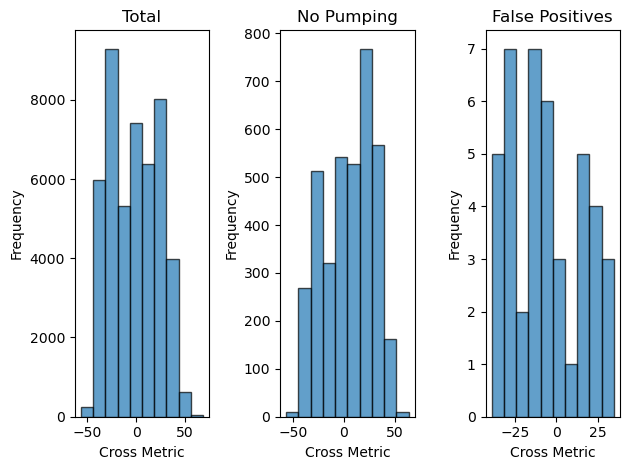

In [59]:
LU_array_no_pumping = zero_pumping[:, 9]

plt.subplot(1, 3, 1)
plt.hist(X[:,9], edgecolor='black', alpha=0.7)
plt.xlabel('Cross Metric')
plt.ylabel('Frequency')
plt.title('Total')

plt.subplot(1, 3, 2)
plt.hist(LU_array_no_pumping, edgecolor='black', alpha=0.7)
plt.xlabel('Cross Metric')
plt.ylabel('Frequency')
plt.title('No Pumping')

# Histogram for Landcover/use types with false positives
LU_array_false_pos = false_pos[:, 9]
plt.subplot(1, 3, 3)
plt.hist(LU_array_false_pos, edgecolor='black', alpha=0.7)
plt.xlabel('Cross Metric')
plt.ylabel('Frequency')
plt.title('False Positives')

plt.tight_layout()
plt.savefig('crossmetric_hist', dpi=300)

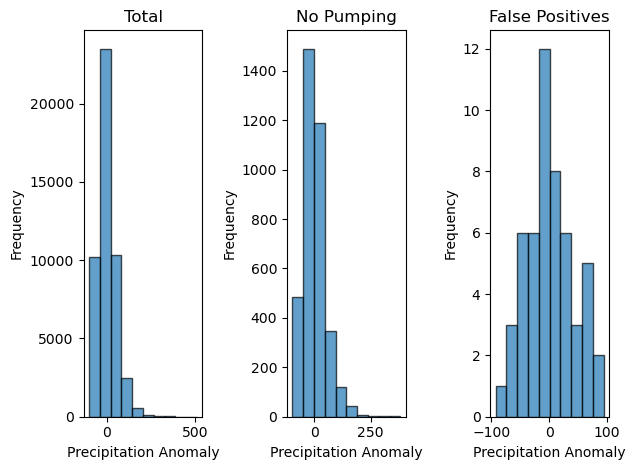

In [76]:
# Frequency of Precipitation Anomaly Values in No Pumping Sites and False Positives
LU_array_no_pumping = zero_pumping[:, 0]
plt.subplot(1, 3, 1)
plt.hist(X[:,0], edgecolor='black', alpha=0.7)
plt.xlabel('Precipitation Anomaly')
plt.ylabel('Frequency')
plt.title('Total')

plt.subplot(1, 3, 2)
plt.hist(LU_array_no_pumping, edgecolor='black', alpha=0.7)
plt.xlabel('Precipitation Anomaly')
plt.ylabel('Frequency')
plt.title('No Pumping')

# Histogram with false positives
LU_array_false_pos = false_pos[:, 0]
plt.subplot(1, 3, 3)
plt.hist(LU_array_false_pos, edgecolor='black', alpha=0.7)
plt.xlabel('Precipitation Anomaly')
plt.ylabel('Frequency')
plt.title('False Positives')

plt.tight_layout()
plt.show()

# Most are near 0 and no more than 100
# More precipitation helps replenish GWL, so more likely to predict 0 pumping
# When precipitation is on the lower side, the model is more likely to predict pumping because less precipitation 
# is associated with lower GWL, and lower GWL could imply pumping took place

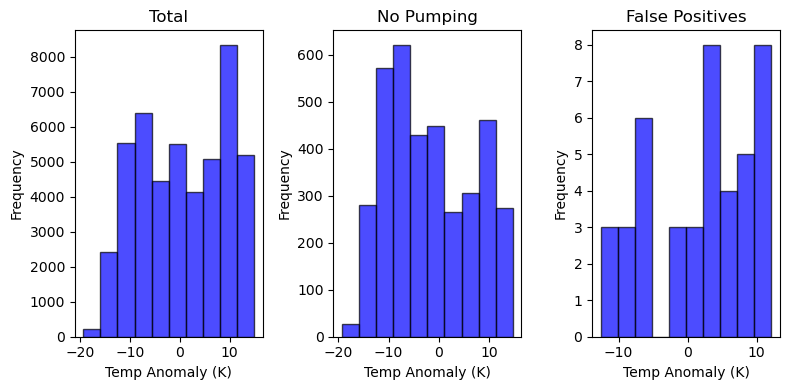

In [21]:
# Frequency of Temperature Anomaly Values in No Pumping Sites and False Positives
LU_array_no_pumping = zero_pumping[:, 1]

plt.figure(figsize=(8, 4))

plt.subplot(1, 3, 1)
plt.hist(X[:,1], edgecolor='black', color='blue', alpha=0.7)
plt.xlabel('Temp Anomaly (K)')
plt.ylabel('Frequency')
plt.title('Total')

plt.subplot(1, 3, 2)
plt.hist(LU_array_no_pumping, edgecolor='black', color='blue', alpha=0.7)
plt.xlabel('Temp Anomaly (K)')
plt.ylabel('Frequency')
plt.title('No Pumping')

# Histogram with false positives
LU_array_false_pos = false_pos[:, 1]
plt.subplot(1, 3, 3)
plt.hist(LU_array_false_pos, edgecolor='black', color='blue', alpha=0.7)
plt.xlabel('Temp Anomaly (K)')
plt.ylabel('Frequency')
plt.title('False Positives')

plt.tight_layout()
plt.savefig('temp_hist', dpi=300)

# Higher temperatures led to false positives
# More pumping takes place during hotter temperatures so more likely to predict nonzero pumping

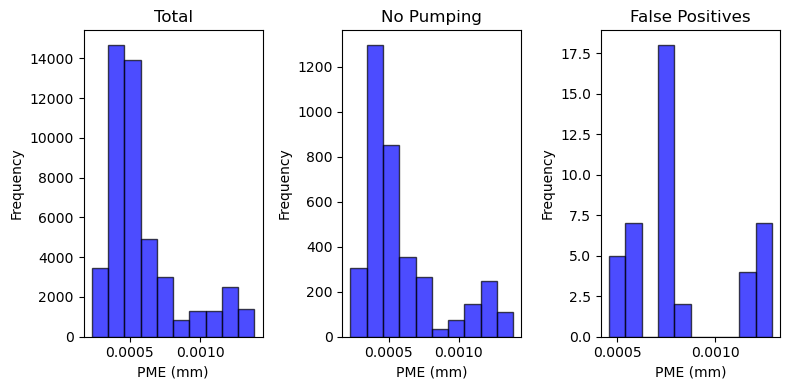

In [31]:
# Frequency of PME Values in No Pumping Sites and False Positives
LU_array_no_pumping = zero_pumping[:, 2]

plt.figure(figsize=(8, 4))

plt.subplot(1, 3, 1)
plt.hist(X[:,2], edgecolor='black', color='blue', alpha=0.7)
plt.xlabel('PME (mm)')
plt.ylabel('Frequency')
plt.title('Total')

plt.subplot(1, 3, 2)
plt.hist(LU_array_no_pumping, edgecolor='black', color='blue', alpha=0.7)
plt.xlabel('PME (mm)')
plt.ylabel('Frequency')
plt.title('No Pumping')

# Histogram with false positives
LU_array_false_pos = false_pos[:, 2]
plt.subplot(1, 3, 3)
plt.hist(LU_array_false_pos, edgecolor='black', color='blue', alpha=0.7)
# plt.xlim(0.00055, 0.0008)
plt.xticks([0.0005, 0.001], labels=['0.0005', '0.0010'])
plt.xlabel('PME (mm)')
plt.ylabel('Frequency')
plt.title('False Positives')

plt.tight_layout()
plt.savefig('PME_hist.png', dpi=300)

# More PME suggests GWL recharge - lower values of it can be associated with lower GWLs, 
# which is also associated with pumping

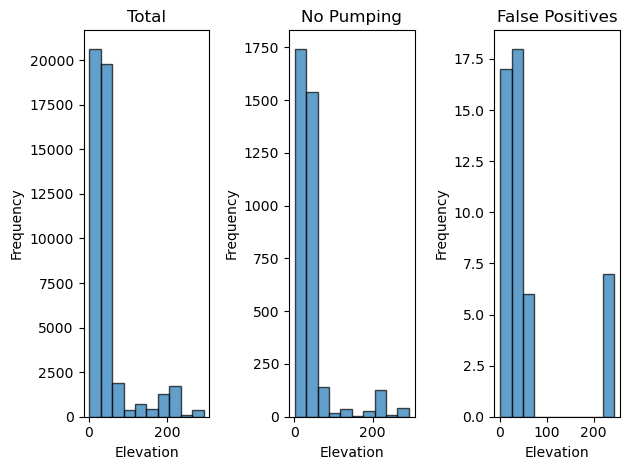

In [216]:
# Frequency of Elev Values in No Pumping Sites and False Positives
LU_array_no_pumping = zero_pumping[:, 3]
plt.subplot(1, 3, 1)
plt.hist(X[:,3], edgecolor='black', alpha=0.7)
plt.xlabel('Elevation')
plt.ylabel('Frequency')
plt.title('Total')

plt.subplot(1, 3, 2)
plt.hist(LU_array_no_pumping, edgecolor='black', alpha=0.7)
plt.xlabel('Elevation')
plt.ylabel('Frequency')
plt.title('No Pumping')

# Histogram with false positives
LU_array_false_pos = false_pos[:, 3]
plt.subplot(1, 3, 3)
plt.hist(LU_array_false_pos, edgecolor='black', alpha=0.7)
plt.xlabel('Elevation')
plt.ylabel('Frequency')
plt.title('False Positives')

plt.tight_layout()
plt.show()

# Higher elevation - less likely to get water to flow here to recharge GWL - so maybe they have lower GWL, which
# implies pumping could have happened

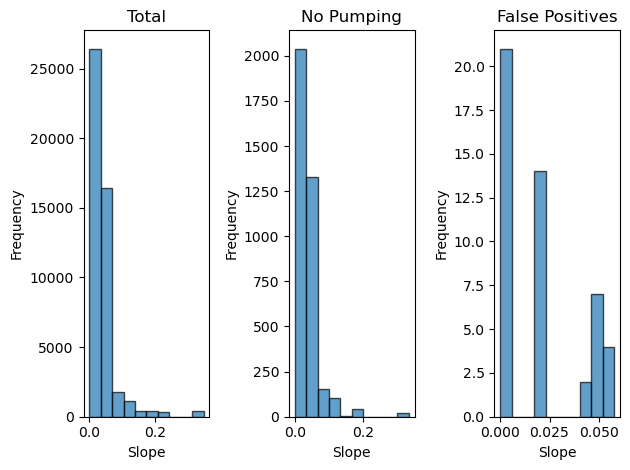

In [217]:
# Frequency of Slope Values in No Pumping Sites and False Positives
LU_array_no_pumping = zero_pumping[:, 4]
plt.subplot(1, 3, 1)
plt.hist(X[:,4], edgecolor='black', alpha=0.7)
plt.xlabel('Slope')
plt.ylabel('Frequency')
plt.title('Total')

plt.subplot(1, 3, 2)
plt.hist(LU_array_no_pumping, edgecolor='black', alpha=0.7)
plt.xlabel('Slope')
plt.ylabel('Frequency')
plt.title('No Pumping')

# Histogram with false positives
LU_array_false_pos = false_pos[:, 4]
plt.subplot(1, 3, 3)
plt.hist(LU_array_false_pos, edgecolor='black', alpha=0.7)
plt.xlabel('Slope')
plt.ylabel('Frequency')
plt.title('False Positives')

plt.tight_layout()
plt.show()

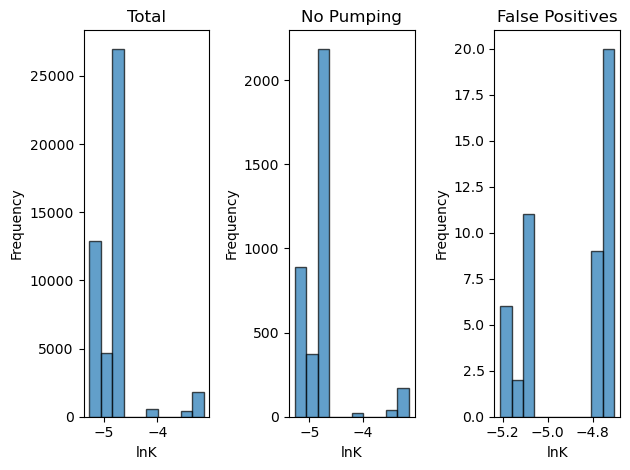

In [218]:
# Frequency of lnK Values in No Pumping Sites and False Positives
plt.subplot(1, 3, 1)
plt.hist(X[:,5], edgecolor='black', alpha=0.7)
plt.xlabel('lnK')
plt.ylabel('Frequency')
plt.title('Total')

LU_array_no_pumping = zero_pumping[:, 5]
plt.subplot(1, 3, 2)
plt.hist(LU_array_no_pumping, edgecolor='black', alpha=0.7)
plt.xlabel('lnK')
plt.ylabel('Frequency')
plt.title('No Pumping')

# Histogram with false positives
LU_array_false_pos = false_pos[:, 5]
plt.subplot(1, 3, 3)
plt.hist(LU_array_false_pos, edgecolor='black', alpha=0.7)
plt.xlabel('lnK')
plt.ylabel('Frequency')
plt.title('False Positives')

plt.tight_layout()
plt.show()

# On the lower side - urban areas tend to have impervious land such as roads, so correlation - less GWL recharge

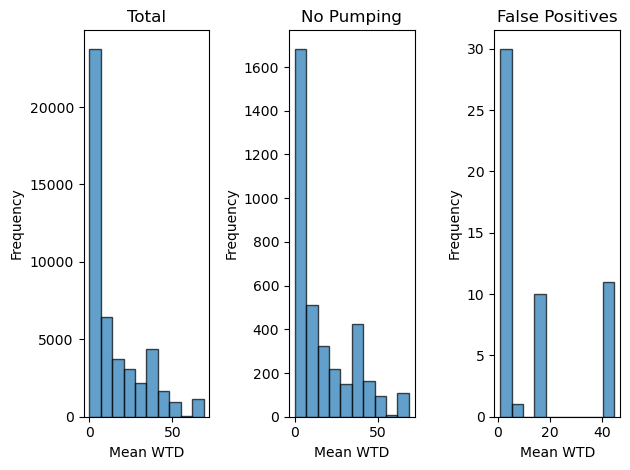

In [78]:
# Frequency of Mean WTD Values in No Pumping Sites and False Positives
LU_array_no_pumping = zero_pumping[:, 6]
plt.subplot(1, 3, 1)
plt.hist(X[:,6], edgecolor='black', alpha=0.7)
plt.xlabel('Mean WTD')
plt.ylabel('Frequency')
plt.title('Total')

plt.subplot(1, 3, 2)
plt.hist(LU_array_no_pumping, edgecolor='black', alpha=0.7)
plt.xlabel('Mean WTD')
plt.ylabel('Frequency')
plt.title('No Pumping')

# Histogram with false positives
LU_array_false_pos = false_pos[:, 6]
plt.subplot(1, 3, 3)
plt.hist(LU_array_false_pos, edgecolor='black', alpha=0.7)
plt.xlabel('Mean WTD')
plt.ylabel('Frequency')
plt.title('False Positives')

plt.tight_layout()
plt.show()

# Smaller mwtd tend to have false positives - pumping is usually correlated with lower mwtd
# It makes sense for no pumping to happen more for areas with little mwtd

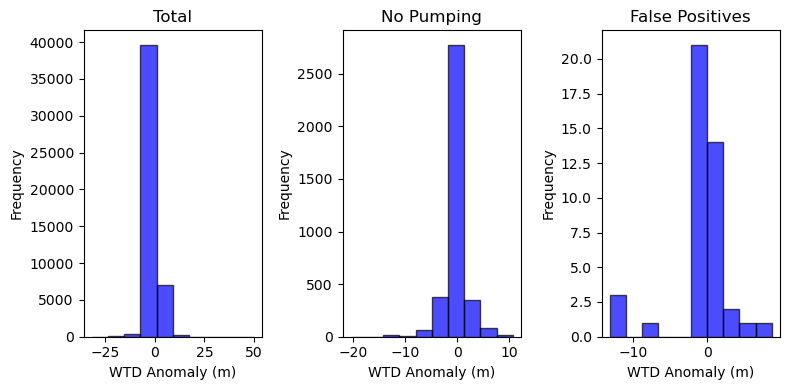

In [23]:
# Frequency of WTD Anomaly Values in No Pumping Sites and False Positives

plt.figure(figsize=(8, 4))

plt.subplot(1, 3, 1)
plt.hist(X[:,7], edgecolor='black', color='blue', alpha=0.7)
plt.xlabel('WTD Anomaly (m)')
plt.ylabel('Frequency')
plt.title('Total')

LU_array_no_pumping = zero_pumping[:, 7]
plt.subplot(1, 3, 2)
plt.hist(LU_array_no_pumping, edgecolor='black', color='blue', alpha=0.7)
plt.xlabel('WTD Anomaly (m)')
plt.ylabel('Frequency')
plt.title('No Pumping')

# Histogram with false positives
LU_array_false_pos = false_pos[:, 7]
plt.subplot(1, 3, 3)
plt.hist(LU_array_false_pos, edgecolor='black', color='blue', alpha=0.7)
# plt.xlim(-0.01, 0.01)
plt.xlabel('WTD Anomaly (m)')
plt.ylabel('Frequency')
plt.title('False Positives')

plt.tight_layout()
plt.savefig('wtd_hist.png', dpi=300)

# Above 0 wtd anomalies tend to have false positives because pumping is assumed to have happened 
# (positive wtd anomaly = GWL is less than the mean GWL)

# Testing the Inverse Model

In [42]:
'''
Dataloader for WTD anomaly estimation over NJ
'''

class WTD_Anomaly_Estimation_NJ_Dataset(Dataset):
    '''
    Return input dataset used to contruct ML models for estimating water table depth (WTD) anomaly
    over NJ for a specific date.

    Input data are:
                    1. P anomaly;
                    2. T anomaly;
                    3. precipitation minus evapotranspiration (PME);
                    4. elevation (elev);
                    5. topographic slope (slope);
                    6. natural log of hydraulic conductivity (lnK);
                    7. estimated long-term mean WTD (mwtd);
                    8. Land cover

    Output data are: water table depth anomaly (wtd_a)

    :param in_vars:
        Input variables.
    :param out_vars:
        Output variables.
    :param date:
        Study date. Format: 'YYYY-MM-DD'.
    :param base_dirs:
        Locations of data used to construct ML models. 
    '''
    def __init__(
        self,
        in_vars=None,
        out_vars=None,
        study_date=None,
        base_dirs=['/home/SHARED/data/ym5379/WTD_RF_estimates/CONUS2_input/',
                   '/home/SHARED/data/ym5379/NJ_experiment/NJ_data/',
                   '/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/',
                   '/hydrodata/forcing/processed_data/CONUS2/CW3E/monthly/']
    ):
        super().__init__()
        self.in_vars = in_vars
        self.out_vars = out_vars
        
        #Load location files
        x_pixel_arr_all = np.load(base_dirs[2]+'x_indexes_90m_NJ.npy')
        y_pixel_arr_all = np.load(base_dirs[2]+'y_indexes_90m_NJ.npy')
        
        x_pixel_arr_all_GW_withdrawal = np.load(base_dirs[2]+'x_indexes_90m_Withdrawals_NJ.npy')
        y_pixel_arr_all_GW_withdrawal = np.load(base_dirs[2]+'y_indexes_90m_Withdrawals_NJ.npy')
        
        mask = np.isnan(x_pixel_arr_all) + np.isnan(y_pixel_arr_all) + np.isnan(x_pixel_arr_all_GW_withdrawal) + np.isnan(y_pixel_arr_all_GW_withdrawal)

        mask[mask>0] = 1

        x_pixel_arr_all[np.isnan(x_pixel_arr_all)] = 0
        y_pixel_arr_all[np.isnan(y_pixel_arr_all)] = 0
        
        x_pixel_arr_all_GW_withdrawal[np.isnan(x_pixel_arr_all_GW_withdrawal)] = 0
        y_pixel_arr_all_GW_withdrawal[np.isnan(y_pixel_arr_all_GW_withdrawal)] = 0

        n_features = len(in_vars)
        nx = x_pixel_arr_all.shape[1]
        ny = x_pixel_arr_all.shape[0]

        x_new = np.empty([n_features,nx*ny],dtype=np.float32)
        y_new = np.empty([1,nx*ny],dtype=np.float32)
    
        ##Load input data##  
        #PME
        x_new[2,:] = read_pfb(base_dirs[0]+'1km_CONUS2_PME_fixed_GPU.pfb')[9,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                  x_pixel_arr_all.reshape(-1).astype(int)]
        #lnK
        x_new[5,:] = read_pfb(base_dirs[0]+'lnK_CONUS2.pfb')[0,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                    x_pixel_arr_all.reshape(-1).astype(int)]
        
        #Elev
        elev_dataset = rioxarray.open_rasterio(base_dirs[1]+'NJ_3s_DEM.tif')
        elev_dataset = elev_dataset.astype('float32')

        elev_data = elev_dataset.data
        x_new[3,:] = elev_data[0,:,:].reshape(-1)
        
        #Slope
        slope_dataset = rioxarray.open_rasterio(base_dirs[1]+'NJ_3s_slope.tif')
        slope_data = slope_dataset.data
        slope_data[slope_data==-9999.0] = np.nan
        slope_data = np.tan(slope_data*np.pi/180)
        x_new[4,:] = slope_data[0,:,:].reshape(-1)
        
        #mwtd
        x_new[6,:] = rioxarray.open_rasterio(base_dirs[2]+'wtd_mean_estimate_RF_3s_CONUS_model_NJ_m_v_20230519.tif').data[0,:,:].reshape(-1)
        
        #GW pumping
        HUC14 = rioxarray.open_rasterio(base_dirs[1]+'NJ_90m_HUC14.tif').data[0,:,:][y_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int),
                                                                                                    x_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int)]
        
        
        #Landcover
        land_cover = rioxarray.open_rasterio('/home/jk48/Senior_Thesis/land_cover.tif').data[0,:,:][y_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int),
                                                                                                    x_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int)]
        
        
        lu = category_map(land_cover)
        
        x_new[8,:] = lu
        
        #wtd-mwtd
        wtd_anomaly = pd.read_csv('/home/jk48/Senior_Thesis/wtd_predictions.csv')
        x_new[7,:] = wtd_anomaly['wtd_est']
        
        wtd_anomaly[wtd_anomaly['wtd_est']==wtd_anomaly['wtd_est'][0]]=np.nan
        wtd_std = wtd_anomaly['wtd_est'].std()
        
        wtd_anomaly = pd.read_csv('/home/jk48/Senior_Thesis/wtd_predictions.csv')

#         # Lower Range (value - std)
#         low_wtd = wtd_anomaly['wtd_est'] - wtd_std
#         x_new[7,:] = low_wtd

        # Upper Range (value + std)
        upp_wtd = wtd_anomaly['wtd_est'] + wtd_std
        x_new[7,:] = upp_wtd
        
        #P & T anomaly 
        year = pd.to_datetime(study_date).year
        month = pd.to_datetime(study_date).month

        #Water Year
        if month > 9:
            year_d = year + 1
            index = month - 10
        else:
            year_d = year 
            index = month + 12 - 10
        
        P_arr = read_pfb(base_dirs[3]+'CW3E.APCP.monthly.sum.WY'+str(year_d)+'.pfb')[index,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                                x_pixel_arr_all.reshape(-1).astype(int)]
        T_arr = read_pfb(base_dirs[3]+'CW3E.Temp.monthly.mean.WY'+str(year_d)+'.pfb')[index,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                                x_pixel_arr_all.reshape(-1).astype(int)]


        lmeanP_data = read_pfb(base_dirs[0]+'long_term_mean_monthly_precipitation_CONUS2.pfb')[0,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                                x_pixel_arr_all.reshape(-1).astype(int)]
        lmeanT_data = read_pfb(base_dirs[0]+'long_term_mean_monthly_temperature_CONUS2.pfb')[0,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                                x_pixel_arr_all.reshape(-1).astype(int)]
        
        x_new[0,:] = P_arr - lmeanP_data
        x_new[1,:] = T_arr - lmeanT_data
        
        # Cross metric (best performance)
        for i in range(6260800):
            if x_new[2, i] > 0.0055 and x_new[2, i] < 0.0008:
                x_new[2, i] = 0
            else:
                x_new[2, i] = 1
            if x_new[8,i] == 1 or x_new[8,i] == 4:
                x_new[8,i] = 0
            else:
                x_new[8,i] = 1
            if x_new[7,i] > -0.01 and x_new[7,i] < 0.01:
                x_new[7,i] = 0
            else:
                x_new[7,i] = 1
        
        x_new[9,:] = (x_new[2,:] + x_new[7,:] + x_new[5,:]) * x_new[1,:]
        
        x_new[8,:] = lu
        
        x_new[2,:] = read_pfb(base_dirs[0]+'1km_CONUS2_PME_fixed_GPU.pfb')[9,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                                  x_pixel_arr_all.reshape(-1).astype(int)]
        x_new[5,:] = read_pfb(base_dirs[0]+'lnK_CONUS2.pfb')[0,:,:][y_pixel_arr_all.reshape(-1).astype(int),
                                                                    x_pixel_arr_all.reshape(-1).astype(int)]
        x_new[7,:] = wtd_anomaly['wtd_est']
#         x_new[7,:] = low_wtd
        x_new[7,:] = upp_wtd
        
        #GW pumping
        HUC14 = rioxarray.open_rasterio(base_dirs[1]+'NJ_90m_HUC14.tif').data[0,:,:][y_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int),
                                                                                                    x_pixel_arr_all_GW_withdrawal.reshape(-1).astype(int)]
        
        #Load Pumping data
        GW_withdrawal_dataset = pd.read_csv('/home/SHARED/data/ym5379/NJ_pumping_records/DGS10-3-With-HUC/HUCWithdrawal.csv')
        GW_withdrawal_dataset['Date'] = pd.to_datetime(GW_withdrawal_dataset.YearNumber.astype(str)+'/'+GW_withdrawal_dataset.MonthNumber.astype(str)+'/01')
        GW_withdrawal_dataset = GW_withdrawal_dataset.drop(columns=['SiteName','YearNumber','MonthNumber','TransferEffectiveDate','DataSource'])

        GW_withdrawal_dataset = GW_withdrawal_dataset[GW_withdrawal_dataset['Date']==study_date]
        
        GW_withdrawal_90m_data = np.empty(ny*nx) * np.nan
        count = 0

        for HUC14_index in np.unique(HUC14[~np.isnan(HUC14)]):

            if GW_withdrawal_dataset[GW_withdrawal_dataset['HUC14']==int(HUC14_index)].shape[0] != 0:
                GW_withdrawal_90m_data[HUC14==HUC14_index] = GW_withdrawal_dataset[GW_withdrawal_dataset['HUC14']==int(HUC14_index)]['WithdrawalMG'].mean()
            else:
                count += 1
                GW_withdrawal_90m_data[HUC14==HUC14_index] = 0
                
        
        y_new[0,:] = GW_withdrawal_90m_data
        
        
        #Set mask as nan
        mask = mask.reshape(-1) + np.isnan(x_new[5,:]) + np.isnan(x_new[3,:]) + np.isnan(x_new[4,:]) + np.isnan(x_new[6,:]) + np.isnan(x_new[7,:])
        mask[mask>1] = 1
        
        x_new[:,mask] = -9999
        y_new[:,mask] = -9999
        
        self.in_data = torch.from_numpy(np.stack(x_new)).type(torch.float32).reshape(n_features,-1)
        self.out_data = torch.from_numpy(np.stack(y_new)).type(torch.float32).reshape(1,-1)
        self.x_pixel_arr_all = torch.from_numpy(x_pixel_arr_all).type(torch.float32)
        self.mask = torch.from_numpy(mask).type(torch.float32)
        self.lu = torch.from_numpy(lu).type(torch.float32)

        
    def __getitem__(self, idx):
        return self.in_data[:,idx], self.x_pixel_arr_all, self.mask, self.lu, self.out_data[:,idx]

    def __len__(self):
        return self.in_data.shape[1]

    def is_numpy(self):
        return (self.in_data.numpy(), self.out_data.numpy())

In [43]:
def category_map(arr):

    category_mapping = {
        (0, 2000): 1,
        (2000, 3000): 4,
        (4000, 5000): 3,
        (5000, 8000): 2
    }

    # Replace categories with mapped values
    mapped_arr = np.zeros_like(arr)
    for category_range, mapped_value in category_mapping.items():
        lower_bound, upper_bound = category_range
        mapped_arr[(arr >= lower_bound) & (arr < upper_bound)] = mapped_value
    
    return mapped_arr

In [55]:
in_vars = ['P-mP','T-mT','PME','elev','slope','lnK','mwtd','wtd-mwtd','land_cover','cross_metric'] # Need WTD as an input
out_vars = ['pumping']

In [56]:
input_dataset = WTD_Anomaly_Estimation_NJ_Dataset(in_vars, out_vars,
                                                  study_date='2015-01-01')
    
X_tensor, X_pixel_tensor, mask_tensor, lu_tensor, y_tensor = input_dataset[:]
X = np.swapaxes(X_tensor.numpy(),0,1)#input shape (n_samples, n_features)
y = np.swapaxes(y_tensor.numpy(),0,1)
X_pixel_array = X_pixel_tensor.numpy()
mask_real = mask_tensor.numpy()
lu = lu_tensor.numpy()

In [59]:
yy = y.copy()
yy = yy[yy != -9999.0]
yy = yy[yy != 4507.0]

In [20]:
y.shape

(6260800, 1)

In [57]:
lasso_results = lasso_model.predict(X)
results = []

#Obtain results from each tree
for n in range(n_estimators):
    results.append(estimators[n].predict(X))
    
predictions = np.mean(np.array(results),axis=0)+lasso_results
predictions

array([51344.70878258, 51344.70878258, 51344.70878258, ...,
       51344.70878258, 51344.70878258, 51344.70878258])

In [14]:
test_indices = np.where(lasso_results != lasso_results[0])[0]
results_arr = np.array(results)
test_results = results_arr[:,test_indices]
test_y = y[test_indices,:]
test_lasso = lasso_results[test_indices]

test_r2_score = r2_score(test_y,np.median(np.array(test_results),axis=0)+test_lasso)
test_rmse_score = mse(test_y,np.mean(np.array(test_results),axis=0)+test_lasso,squared=False)
test_r_score = stats.pearsonr(test_y.reshape(-1),np.median(np.array(test_results),axis=0)+test_lasso)[0]

print('Test NSE:',test_r2_score)
print('Test RMSE:',test_rmse_score)
print('Test R:',test_r_score)

Test NSE: -0.07782977737388608
Test RMSE: 151.94160889491687
Test R: -0.011554487058094316


In [62]:
df1 = pd.DataFrame(y)
df2 = pd.DataFrame(lu)
y_lu = pd.concat([df1, df2], axis=1)
y_lu = pd.DataFrame(data=y_lu.values, columns=['Y', 'LU'])
y_lu[y_lu['Y']==-9999.0]=np.nan
#means = y_pred.groupby('Y')['LU'].transform('mean')

average_values = y_lu.groupby('LU')['Y'].mean().reset_index()
category_mapping = {1:'URBAN', 2:'WETLANDS', 3:'FOREST', 4:'AGRICULTURE'}
average_values['LU'] = average_values['LU'].map(category_mapping)
average_values.rename(columns={'LU':'Land Use Type', 'Y': 'GWP'},inplace=True)
average_values 

,Land Use Type,GWP
0,URBAN,8.984904
1,WETLANDS,1.918780
2,FOREST,1.840351
3,AGRICULTURE,1.730801


In [61]:
# Group together the true pumping and predicted pumping values together
df1 = pd.DataFrame(y)
df2 = pd.DataFrame(predictions)
y_pred = pd.concat([df1, df2], axis=1)
y_pred = pd.DataFrame(data=y_pred.values, columns=['Y', 'Pred'])
means = y_pred.groupby('Y')['Pred'].transform('mean')
y_pred['Pred'] = means
y_pred['RMSE'] = (y_pred['Y'] - y_pred['Pred'])
y_pred[y_pred['Y']==-9999.0]=np.nan
y_pred[y_pred['Y']>100.0]=np.nan
y_pred[y_pred['Pred']>80]=np.nan
data = y_pred[~np.isnan(y_pred)]

In [77]:
import math
import sklearn.metrics

df = data.copy()
df.dropna(subset=['Y'], inplace=True)
mse = sklearn.metrics.mean_squared_error(df['Y'],df['Pred'])
rmse = math.sqrt(mse)
rmse

5.886157387879462

In [78]:
data.max()

Y       66.810844
Pred    35.159021
RMSE    57.231865
dtype: float64

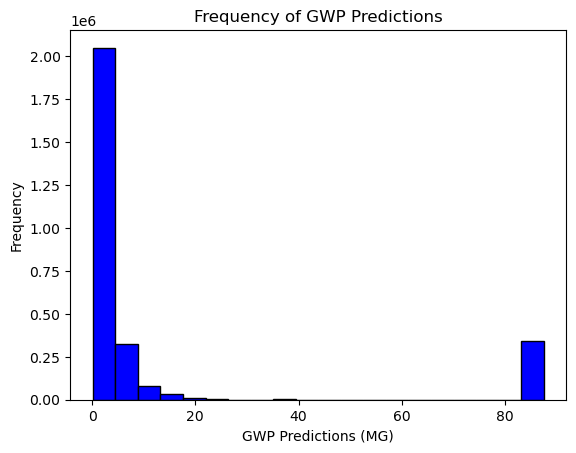

In [100]:
plt.hist(y_pred['Pred'], bins=20, color='blue', edgecolor='black')

# Adding labels and title
plt.xlabel('GWP Predictions (MG)')
plt.ylabel('Frequency')
plt.title('Frequency of GWP Predictions')
plt.savefig('lastgraph_2.png', dpi=300)

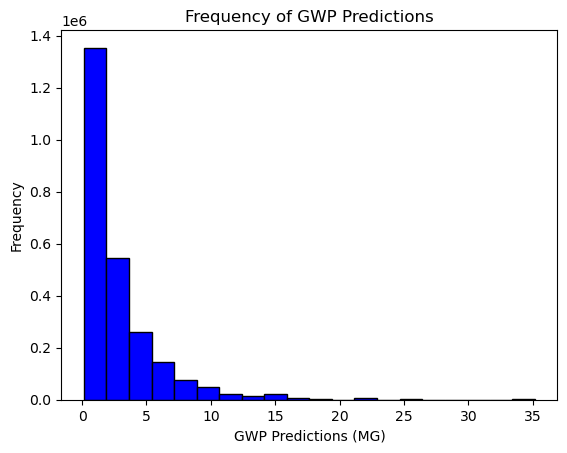

In [102]:
plt.hist(y_pred['Pred'], bins=20, color='blue', edgecolor='black')

# Adding labels and title
plt.xlabel('GWP Predictions (MG)')
plt.ylabel('Frequency')
plt.title('Frequency of GWP Predictions')
plt.savefig('lastgraph_1.png', dpi=300)

In [15]:
#January
print(y_pred['Pred'].mean())
print(y_pred['Pred'].min())
print(y_pred['Pred'].max())
print(y_pred['Pred'].std())

2.8874767003083153
0.1429542316029634
35.15902074573553
3.354644182170946


In [19]:
# July
print(y_pred['Pred'].mean())
print(y_pred['Pred'].min())
print(y_pred['Pred'].max())
print(y_pred['Pred'].std())

3.7609294195049183
0.6944210991440478
27.961390028951318
3.2381019441115875


In [37]:
wtd_anomaly = pd.read_csv('/home/jk48/Senior_Thesis/wtd_predictions.csv')
wtd_anomaly[wtd_anomaly['wtd_est']==wtd_anomaly['wtd_est'][0]]=np.nan
#wtd_anomaly[wtd_anomaly['wtd_est']>100]=np.nan
print(wtd_anomaly['wtd_est'].mean())
print(wtd_anomaly['wtd_est'].median())
print(wtd_anomaly['wtd_est'].max())
print(wtd_anomaly['wtd_est'].min())
print(wtd_anomaly['wtd_est'].std())

-0.30219502783691354
-0.2556915198514858
12.265523408899703
-8.524696787893772
0.612145716413829


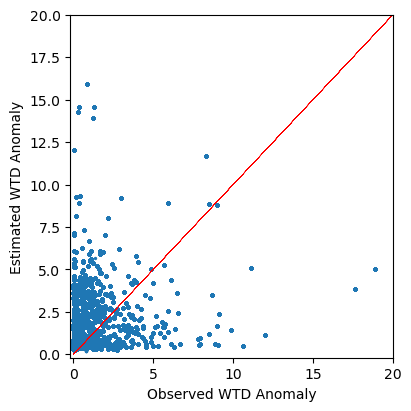

In [22]:
fig, ax1 = plt.subplots(1,1,figsize=(4,4),constrained_layout=True)
ax1.scatter(y_pred['Y'],y_pred['Pred'],s=2)
ax1.plot(y_test,y_test,'r--',lw=0.1)
plt.xlim(-0.2,20)
plt.ylim(-0.2,20)
plt.xlabel('Observed WTD Anomaly')
plt.ylabel('Estimated WTD Anomaly')
plt.savefig('test.png',dpi=300)

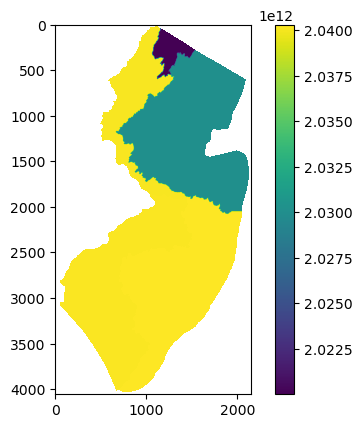

In [14]:
path = '/home/SHARED/data/ym5379/NJ_experiment/NJ_data/'
HUC14_3s_dataset = rioxarray.open_rasterio(path+'NJ_90m_HUC14.tif')


HUC14_3s_data = HUC14_3s_dataset.data[0,:,:]
HUC14_3s_data[HUC14_3s_data==-9999] = np.nan

np.unique(HUC14_3s_data[~np.isnan(HUC14_3s_data)]).shape

plt.imshow(HUC14_3s_data,cmap='viridis')
plt.colorbar()

In [52]:
y_pred

,Y,Pred,RMSE
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
6260795,NaN,NaN,NaN
6260796,NaN,NaN,NaN
6260797,NaN,NaN,NaN
6260798,NaN,NaN,NaN


In [52]:
x_pixel_arr_all = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/x_indexes_90m_NJ.npy')
y_pixel_arr_all = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/y_indexes_90m_NJ.npy')

x_pixel_arr_all_GW_withdrawal = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/x_indexes_90m_Withdrawals_NJ.npy')
y_pixel_arr_all_GW_withdrawal = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/y_indexes_90m_Withdrawals_NJ.npy')
        
mask = np.isnan(x_pixel_arr_all) + np.isnan(y_pixel_arr_all) + np.isnan(x_pixel_arr_all_GW_withdrawal) + np.isnan(y_pixel_arr_all_GW_withdrawal)
mask[mask>0] = 1

x_pixel_arr_all[np.isnan(x_pixel_arr_all)] = 0
y_pixel_arr_all[np.isnan(y_pixel_arr_all)] = 0
        
x_pixel_arr_all_GW_withdrawal[np.isnan(x_pixel_arr_all_GW_withdrawal)] = 0
y_pixel_arr_all_GW_withdrawal[np.isnan(y_pixel_arr_all_GW_withdrawal)] = 0

nx = x_pixel_arr_all_GW_withdrawal.shape[1]
ny = y_pixel_arr_all_GW_withdrawal.shape[0]

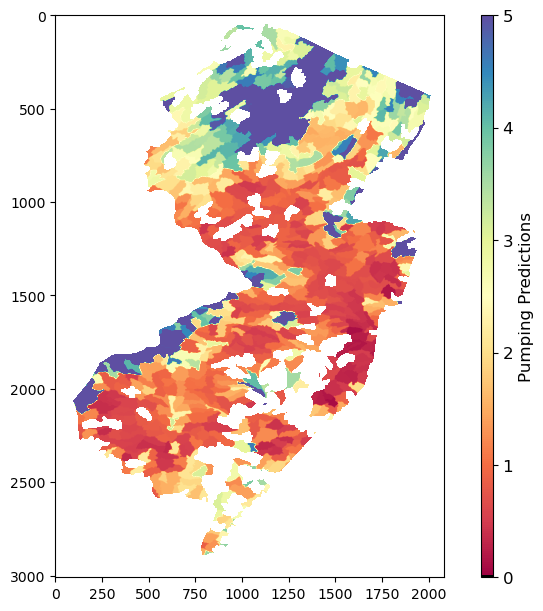

In [66]:
fig, ax1 = plt.subplots(1,1,figsize=(8,6),constrained_layout=True)

custom_value = 0
original_cmap = plt.cm.Spectral
new_color = [0, 0, 255, 1]  # Black color as [R, G, B, alpha]
custom_cmap_colors = [original_cmap(i) for i in range(original_cmap.N)]
custom_cmap_colors[0] = new_color
custom_cmap = ListedColormap(custom_cmap_colors)
vmin = -1

im1 = plt.imshow(y_pred['Pred'].values.reshape(ny,nx), vmin=0, vmax =5, cmap=custom_cmap)
cbar1 = plt.colorbar(im1,ax=ax1,shrink=1,aspect=50,orientation='vertical')
cbar1.set_label('Pumping Predictions',fontsize=12)
cbar1.ax.tick_params(labelsize=12)

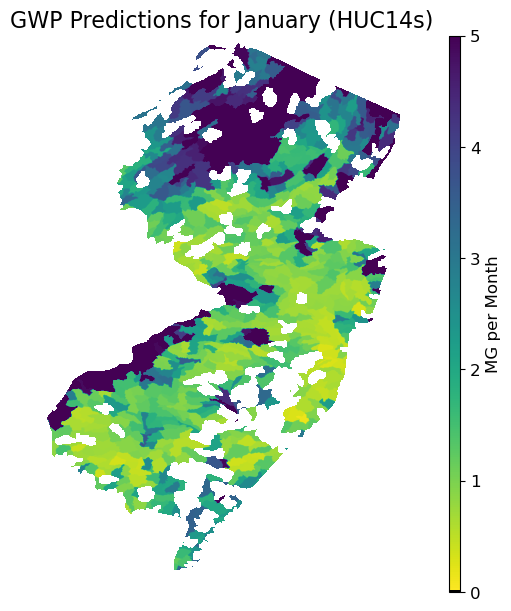

In [62]:
fig, ax1 = plt.subplots(1,1,figsize=(8,6),constrained_layout=True)

custom_value = 0
original_cmap = plt.cm.viridis_r
new_color = [0, 0, 255, 1]  # Black color as [R, G, B, alpha]
custom_cmap_colors = [original_cmap(i) for i in range(original_cmap.N)]
custom_cmap_colors[0] = new_color
custom_cmap = ListedColormap(custom_cmap_colors)
vmin = -1

im1 = plt.imshow(y_pred['Pred'].values.reshape(ny,nx), vmin=0, vmax =5, cmap=custom_cmap)
cbar1 = plt.colorbar(im1,ax=ax1,shrink=1,aspect=50,orientation='vertical')
cbar1.set_label('MG per Month',fontsize=12)
cbar1.ax.tick_params(labelsize=12)

ax1.set_title('GWP Predictions for January (HUC14s)', fontsize=16)
ax1.axis('off')
fig.savefig('gwp_pred_huc14_jan.png', dpi=300)

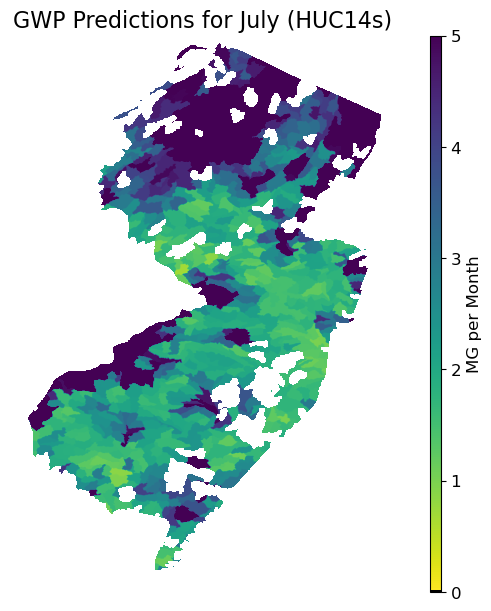

In [53]:
fig, ax1 = plt.subplots(1,1,figsize=(8,6),constrained_layout=True)

custom_value = 0
original_cmap = plt.cm.viridis_r
new_color = [0, 0, 255, 1]  # Black color as [R, G, B, alpha]
custom_cmap_colors = [original_cmap(i) for i in range(original_cmap.N)]
custom_cmap_colors[0] = new_color
custom_cmap = ListedColormap(custom_cmap_colors)
vmin = -1

im1 = plt.imshow(y_pred['Pred'].values.reshape(ny,nx), vmin=0, vmax =5, cmap=custom_cmap)
cbar1 = plt.colorbar(im1,ax=ax1,shrink=1,aspect=50,orientation='vertical')
cbar1.set_label('MG per Month',fontsize=12)
cbar1.ax.tick_params(labelsize=12)

ax1.set_title('GWP Predictions for July (HUC14s)', fontsize=16)
ax1.axis('off')
fig.savefig('gwp_pred_huc14.png', dpi=300)

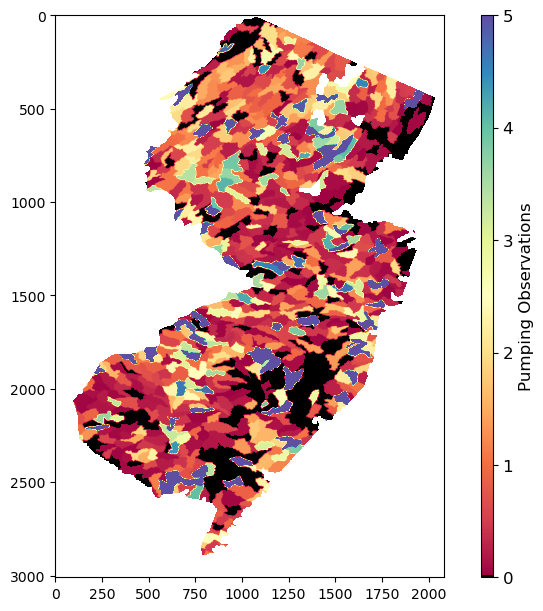

In [16]:
fig, ax1 = plt.subplots(1,1,figsize=(8,6),constrained_layout=True)

custom_value = 0
original_cmap = plt.cm.Spectral
new_color = [0, 0, 255, 1]  # Black color as [R, G, B, alpha]
custom_cmap_colors = [original_cmap(i) for i in range(original_cmap.N)]
custom_cmap_colors[0] = new_color
custom_cmap = ListedColormap(custom_cmap_colors)
vmin = -1

im1 = plt.imshow(y_pred['Y'].values.reshape(ny,nx), vmin=0, vmax =5, cmap=custom_cmap)
cbar1 = plt.colorbar(im1,ax=ax1,shrink=1,aspect=50,orientation='vertical')
cbar1.set_label('Pumping Observations',fontsize=12)
cbar1.ax.tick_params(labelsize=12)

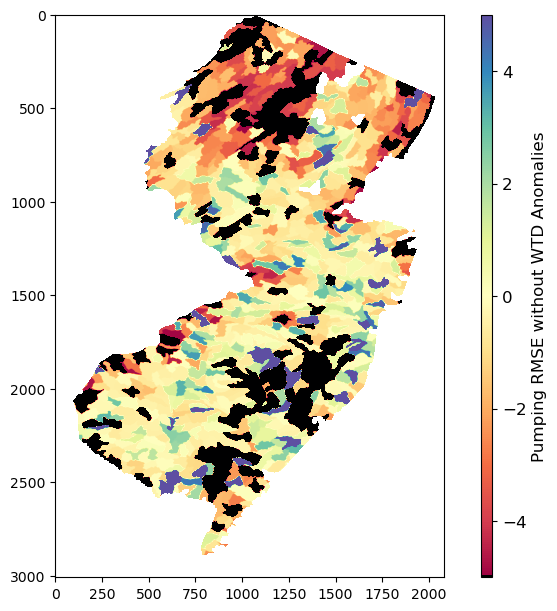

In [29]:
fig, ax1 = plt.subplots(1,1,figsize=(8,6),constrained_layout=True)

custom_value = 0
original_cmap = plt.cm.Spectral
new_color = [0, 0, 255, 1]  # Black color as [R, G, B, alpha]
custom_cmap_colors = [original_cmap(i) for i in range(original_cmap.N)]
custom_cmap_colors[0] = new_color
custom_cmap = ListedColormap(custom_cmap_colors)
vmin = -1

im1 = plt.imshow(y_pred['RMSE'].values.reshape(ny,nx), vmin=-5, vmax =5, cmap=custom_cmap)
cbar1 = plt.colorbar(im1,ax=ax1,shrink=1,aspect=50,orientation='vertical')
cbar1.set_label('Pumping RMSE without WTD Anomalies',fontsize=12)
cbar1.ax.tick_params(labelsize=12)

In [26]:
wtd_anomaly = pd.read_csv('/home/jk48/Senior_Thesis/wtd_predictions.csv')
wtd_anomaly = wtd_anomaly[wtd_anomaly['wtd_est'] < 7160]
wtd_mean = wtd_anomaly['wtd_est'].mean()
wtd_std = wtd_anomaly['wtd_est'].std()
a = wtd_anomaly['wtd_est'].max()

# Lower Range (value - std)
low_wtd = wtd_anomaly['wtd_est'] - wtd_std

# Upper Range (value + std)
upp_wtd = wtd_anomaly['wtd_est'] + wtd_std

print('WTD Mean:', wtd_mean)
print('WTD STD:', wtd_std)

WTD Mean: -0.3021950278369131
WTD STD: 0.612145716413829


In [58]:
pump_pred_df = pd.DataFrame()
pump_pred_df['pump_pred'] = pd.DataFrame(predictions)

# X and Y pixel/grid cells 
X_pixel_array[np.where(X_pixel_array == 0)] = np.nan
not_zero = np.where(X_pixel_array != 0)
Y_pixel = not_zero[0]
X_pixel = not_zero[1]
pump_pred_df['Y'] = pd.DataFrame(Y_pixel, dtype="float64")
pump_pred_df['X'] = pd.DataFrame(X_pixel, dtype="float64")

# new df with all info and drop nan grid cells
data_df = pd.DataFrame()
average_values = pump_pred_df.groupby(['Y','X','pump_pred']).mean()
data_df = average_values.reset_index()
data_df.columns = ['Y','X','pump_est']
out = data_df['pump_est'][0]
data_df = data_df[data_df['pump_est'] != out]
data_df

,Y,X,pump_est
5237,2.0,1077.0,164.892220
5238,2.0,1078.0,162.558816
7315,3.0,1075.0,162.303065
7316,3.0,1076.0,164.774240
7317,3.0,1077.0,162.683257
...,...,...,...
6028623,2898.0,783.0,3.118880
6028624,2898.0,784.0,3.084140
6028625,2898.0,785.0,5.636626
6028626,2898.0,786.0,3.322038


In [59]:
withdrawal = data_df[data_df['pump_est'] < 30]
max_val = withdrawal['pump_est'].max() 
min_val = withdrawal['pump_est'].min() 
mean_val = withdrawal['pump_est'].mean()
stan_dev = withdrawal['pump_est'].std()
print("Maximum:", max_val)
print("Minimum:", min_val)
print("Mean:", mean_val)
print("Standard Deviation:", stan_dev)

Maximum: 29.998629465897878
Minimum: -1.041156390408675
Mean: 2.4691202950425026
Standard Deviation: 3.667225344114303


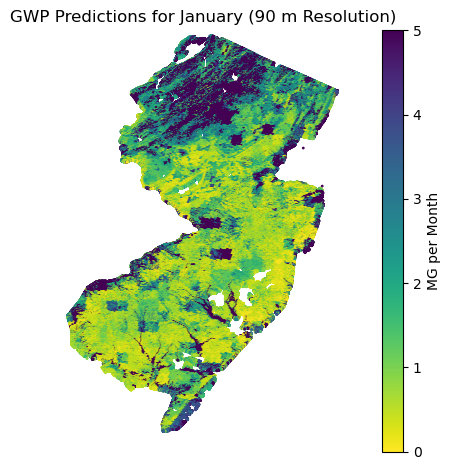

In [60]:
X_pixel_array = np.ones((1, 1))
X_pixel_array.fill(1)
plt.imshow(X_pixel_array)
plt.scatter(withdrawal['X'], withdrawal['Y'], c=withdrawal['pump_est'], cmap='viridis_r', s=1, vmin=0, vmax=5)  # Adjust cmap and s as needed
plt.colorbar().set_label('MG per Month')
plt.axis('off')
plt.title('GWP Predictions for January (90 m Resolution)')
plt.tight_layout()
plt.savefig('gwp_pred_jan.png', dpi=300)

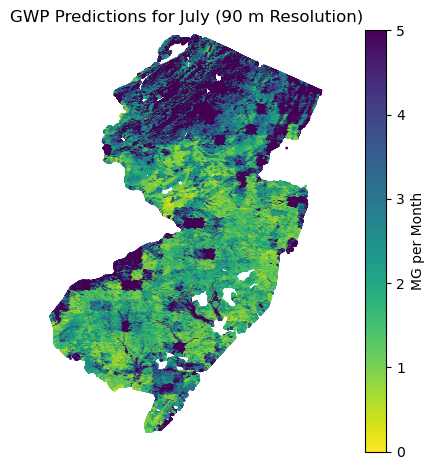

In [49]:
X_pixel_array = np.ones((1, 1))
X_pixel_array.fill(1)
plt.imshow(X_pixel_array)
plt.scatter(withdrawal['X'], withdrawal['Y'], c=withdrawal['pump_est'], cmap='viridis_r', s=1, vmin=0, vmax=5)  # Adjust cmap and s as needed
plt.colorbar().set_label('MG per Month')
plt.axis('off')
plt.title('GWP Predictions for July (90 m Resolution)')
plt.tight_layout()
plt.savefig('gwp_pred.png', dpi=300)

In [ ]:
X_pixel_array = np.ones((1, 1))
X_pixel_array.fill(1)
plt.imshow(X_pixel_array)
plt.scatter(withdrawal['X'], withdrawal['Y'], c=withdrawal['pump_est'], cmap='viridis_r', s=1, vmin=0, vmax=5)  # Adjust cmap and s as needed
plt.colorbar().set_label('MG per Month')
plt.axis('off')
plt.title('GWP Predictions in a 90 Meter Resolution for New Jersey')
plt.tight_layout()
plt.savefig('gwp_pred_july.png', dpi=300)

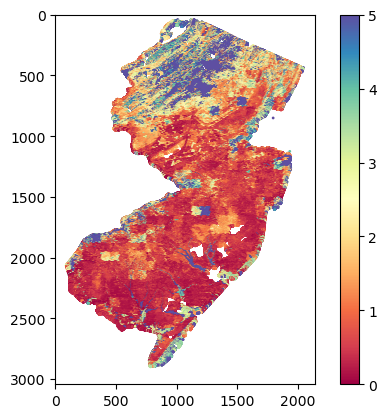

In [16]:
X_pixel_array = np.ones((1, 1))
X_pixel_array.fill(1)
plt.imshow(X_pixel_array)
plt.scatter(withdrawal['X'], withdrawal['Y'], c=withdrawal['pump_est'], cmap='Spectral', s=1, vmin=0, vmax=5)  # Adjust cmap and s as needed
plt.colorbar()
plt.show()

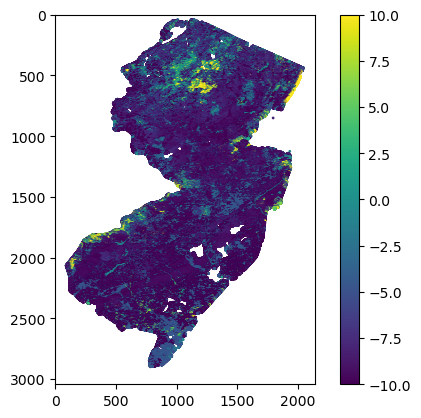

In [36]:
X_pixel_array = np.ones((1, 1))
X_pixel_array.fill(1)
plt.imshow(X_pixel_array)
plt.scatter(withdrawal['X'], withdrawal['Y'], c=withdrawal['pump_est'], cmap='Spectral', s=1, vmin=-10, vmax=10)  # Adjust cmap and s as needed
plt.colorbar()
plt.show()

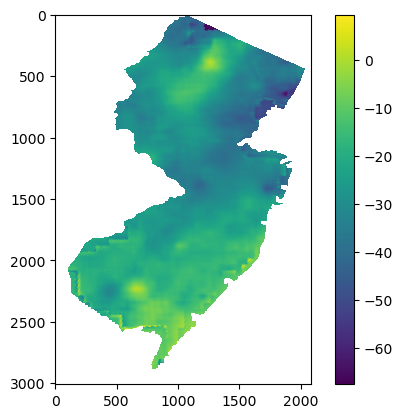

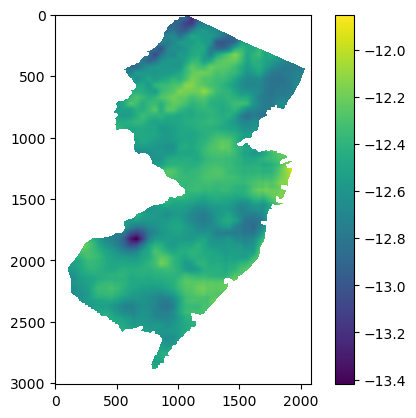

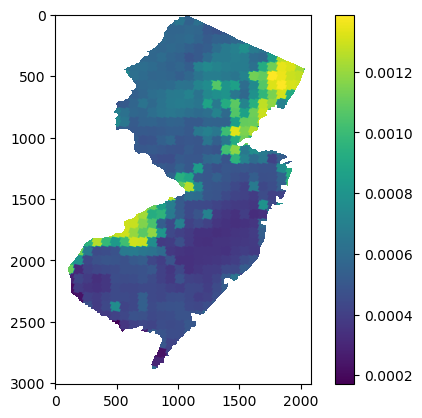

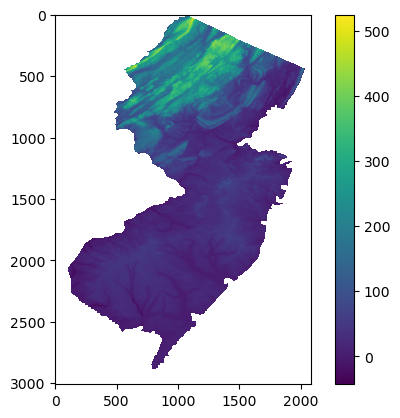

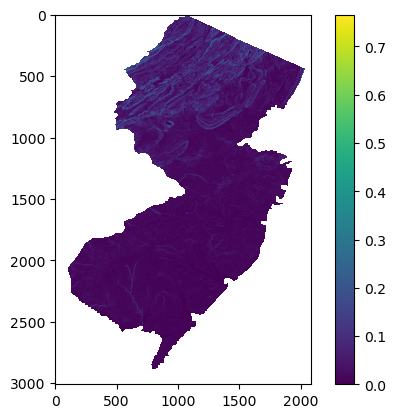

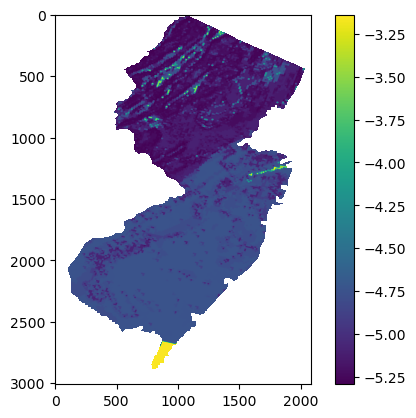

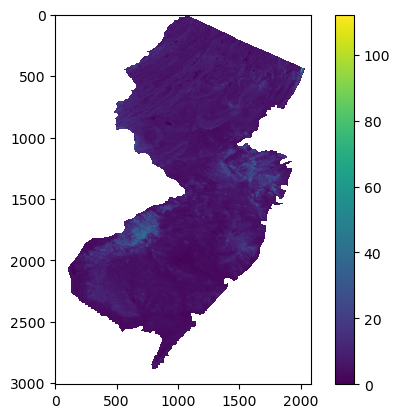

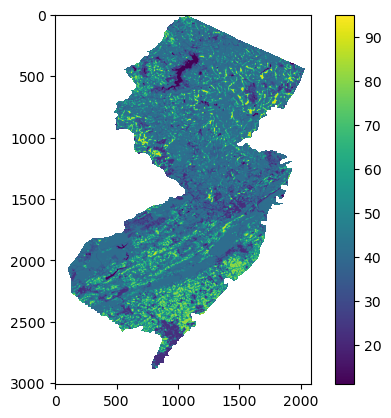

In [28]:
#Test
import matplotlib.pyplot as plt

x_pixel_arr_all = np.load('/home/SHARED/data/ym5379/NJ_experiment/WTD_estimates_NJ/Input_preprocessing/x_indexes_90m_NJ.npy')

nx = x_pixel_arr_all.shape[1]
ny = x_pixel_arr_all.shape[0]

for i in range(8):
    fig = plt.figure()
    plt.imshow(X[:,i].reshape(ny,nx))
    plt.colorbar()
    plt.show()
    
# P anomaly;
# T anomaly;
# precipitation minus evapotranspiration (PME);
# elevation (elev);
# topographic slope (slope);
# natural log of hydraulic conductivity (lnK);
# estimated long-term mean WTD (mwtd);
# land cover